In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib as mpl
from astropy import units
from astropy import constants as const
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from  IPython.display import HTML
from scipy.optimize import curve_fit
from scipy.special import wofz
from scipy.interpolate import interp1d
import time as tt


mpl.rcParams['font.size'] = 16
mpl.rcParams['image.cmap']="Greys_r" 
mpl.rcParams['image.origin']= "lower"

In [2]:
sst4 = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/obssun_sst4/obssun_sst4.h5", "r")
sst4.keys()

<KeysViewHDF5 ['description', 'imagescale', 'intensity', 'lambda0', 'time', 'time_s', 'unit', 'wavelength', 'x', 'y']>

In [3]:
intensity = sst4["intensity"][:]
wavelength = sst4["wavelength"][:]
time = sst4["time"][:]
time_s = sst4["time_s"][:]
x = sst4["x"][:]
y = sst4["y"][:]
c = const.c

In [4]:
# finding central wavelength of Fe I line
FeI_obs = 617.334
FeI = np.mean(wavelength)
thr = 1e-3
search = np.logical_and(wavelength > FeI - thr, wavelength < FeI + thr)
line_core_idx = np.where(search == True)[0][0]
central_lmbda = wavelength[line_core_idx]
print(f"Line core index: {line_core_idx}")
print(f"Central wavelength of Fe I line: {central_lmbda} nm")

Line core index: 7
Central wavelength of Fe I line: 617.3367919921875 nm


In [5]:
# for frame in range(time.size):  
#     fig, ax = plt.subplots(figsize=(8, 6))
#     ax.set_title(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     im = ax.imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity [counts]")
#     plt.tight_layout()
#     # plt.savefig(f"figures/intensity/intensity_{frame:04d}.png")

## 01 Defining subfields in FOV

In [6]:
xy_A_min = 394; xy_A_max = 480
xy_B_min = 118; xy_B_max = 204
xy_C_min = 220; xy_C_max = 306

x_subfield_A = sst4["x"][xy_A_min:xy_A_max]; y_subfield_A = sst4["y"][xy_A_min:xy_A_max]
subfield_A = sst4["intensity"][:, :, xy_A_min:xy_A_max, xy_A_min:xy_A_max]

x_subfield_B = sst4["x"][xy_B_min:xy_B_max]; y_subfield_B = sst4["y"][xy_B_min:xy_B_max]
subfield_B = sst4["intensity"][:, :, xy_B_min:xy_B_max, xy_B_min:xy_B_max]

x_subfield_C = sst4["x"][xy_C_min:xy_C_max]; y_subfield_C = sst4["y"][xy_C_min:xy_C_max]
subfield_C = sst4["intensity"][:, :, xy_C_min:xy_C_max, xy_C_min:xy_C_max]

In [8]:
diff = xy_A_max - xy_A_min
diff_half = int(diff / 2)

x_cent_A = sst4["x"][int((xy_A_max - diff_half))]
y_cent_A = sst4["y"][int(xy_A_max - diff_half)]
print(f"Subfield A center: ({x_cent_A}, {y_cent_A}) arcsec")

x_cent_B = sst4["x"][int((xy_B_max - diff_half))]
y_cent_B = sst4["y"][int(xy_B_max - diff_half)]
print(f"Subfield B center: ({x_cent_B}, {y_cent_B}) arcsec")

x_cent_C = sst4["x"][int((xy_C_max - diff_half))]
y_cent_C = sst4["y"][int(xy_C_max - diff_half)]
print(f"Subfield C center: ({x_cent_C}, {y_cent_C}) arcsec")

# heliocentric coordinates where FOV is centered
x_cent_FOV = -446; y_cent_FOV = 279

x_cent_A_act = x_cent_A + x_cent_FOV
y_cent_A_act = y_cent_A + y_cent_FOV

x_cent_B_act = x_cent_B + x_cent_FOV
y_cent_B_act = y_cent_B + y_cent_FOV

x_cent_C_act = x_cent_C + x_cent_FOV
y_cent_C_act = y_cent_C + y_cent_FOV
print(f"Subfield A center (heliocentric): ({x_cent_A_act}, {y_cent_A_act}) arcsec")
print(f"Subfield B center (heliocentric): ({x_cent_B_act}, {y_cent_B_act}) arcsec")
print(f"Subfield C center (heliocentric): ({x_cent_C_act}, {y_cent_C_act}) arcsec")



Subfield A center: (10.498000144958496, 10.498000144958496) arcsec
Subfield B center: (-5.509999752044678, -5.509999752044678) arcsec
Subfield C center: (0.4059999883174896, 0.4059999883174896) arcsec
Subfield A center (heliocentric): (-435.5019998550415, 289.4980001449585) arcsec
Subfield B center (heliocentric): (-451.5099997520447, 273.4900002479553) arcsec
Subfield C center (heliocentric): (-445.5940000116825, 279.4059999883175) arcsec


In [9]:
print(f"Full fov: ({x[-1]-x[0]: .3f}, {y[-1]-y[0]: .3f}) arcsec")

print(f"FOV, A: ({x[xy_A_max]-x[xy_A_min]: .3f}, {y[xy_A_max]-y[xy_A_min]: .3f}) arcsec")

print(f"FOV, B: ({x[xy_B_max]-x[xy_B_min]: .3f}, {y[xy_B_max]-y[xy_B_min]: .3f}) arcsec")

print(f"Wavelength range: {(wavelength[0]*units.nm).to(units.AA): .2f} - {(wavelength[-1]*units.nm).to(units.AA): .2f}")

Full fov: ( 29.638,  29.638) arcsec
FOV, A: ( 4.988,  4.988) arcsec
FOV, B: ( 4.988,  4.988) arcsec
Wavelength range:  6173.01 Angstrom -  6174.01 Angstrom


## SDO/MHI

In [26]:
SDOMHI_continuum = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/obssun_sst4/obssun_sst4_SDOHMI_continuum.h5", "r")
SDOMHI_magnetogram = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/obssun_sst4/obssun_sst4_SDOHMI_magnetogram.h5", "r")

In [28]:
SDOMHI_magnetogram.keys()

<KeysViewHDF5 ['datentime', 'magnetogram', 'x', 'y']>

In [35]:
SDOMHI_magnetogram.keys()
print(SDOMHI_magnetogram["datentime"])

<HDF5 dataset "datentime": shape (48,), type "|S20">


In [ ]:
# for t in range(len(SDOMHI_magnetogram["datentime"][:])):
#     fig, ax = plt.subplots(figsize=(8, 6))
#     ax.set_title(f"t[{t}] = {SDOMHI_continuum['datentime'][t]}")
#     continuum = ax.imshow(SDOMHI_continuum["intensity"][0, :].T, origin="lower", extent = [np.min(SDOMHI_continuum["x"][:]), np.max(SDOMHI_continuum["x"][:]), np.min(SDOMHI_continuum["y"][:]), np.max(SDOMHI_continuum["y"][:])])
#     fig.colorbar(continuum, ax=ax, fraction=0.046, pad=0.04, label="Intensity")
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     plt.legend()
#     #plt.savefig(f"figures/SDOHMI_continuum/continuum_{t:04d}.png")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

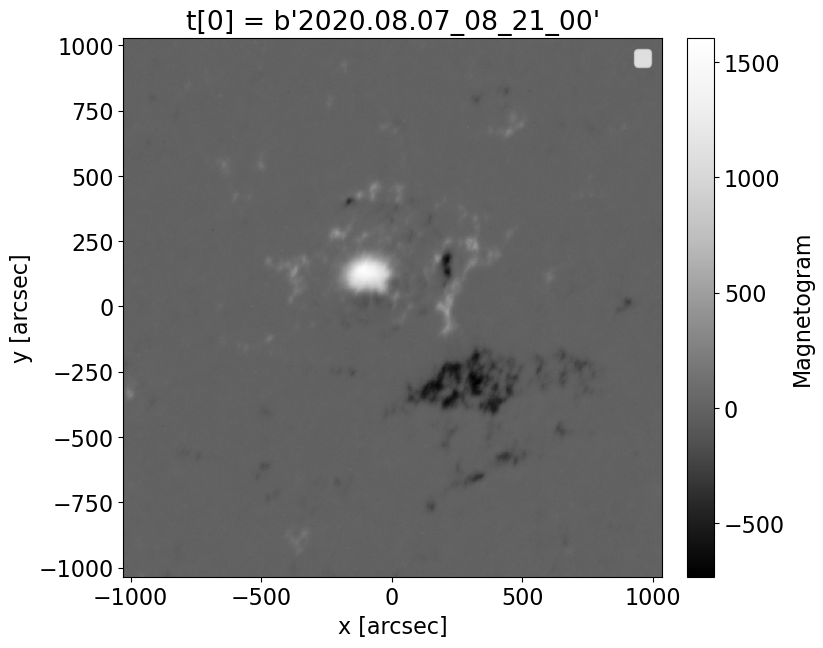

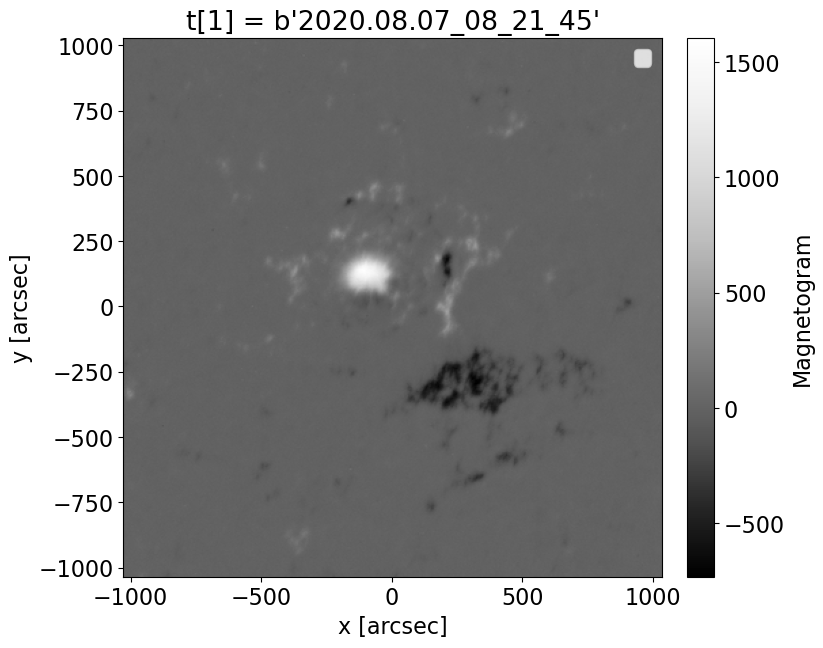

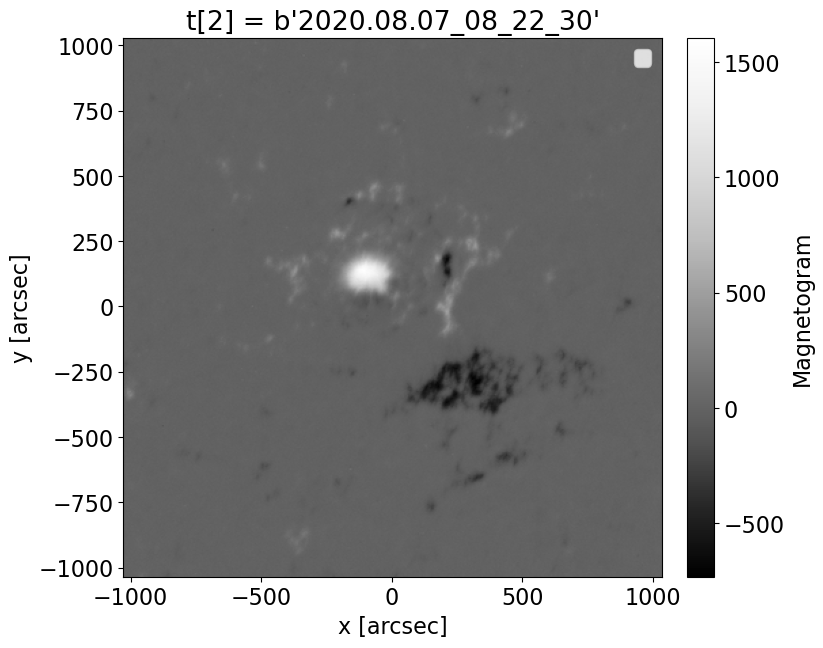

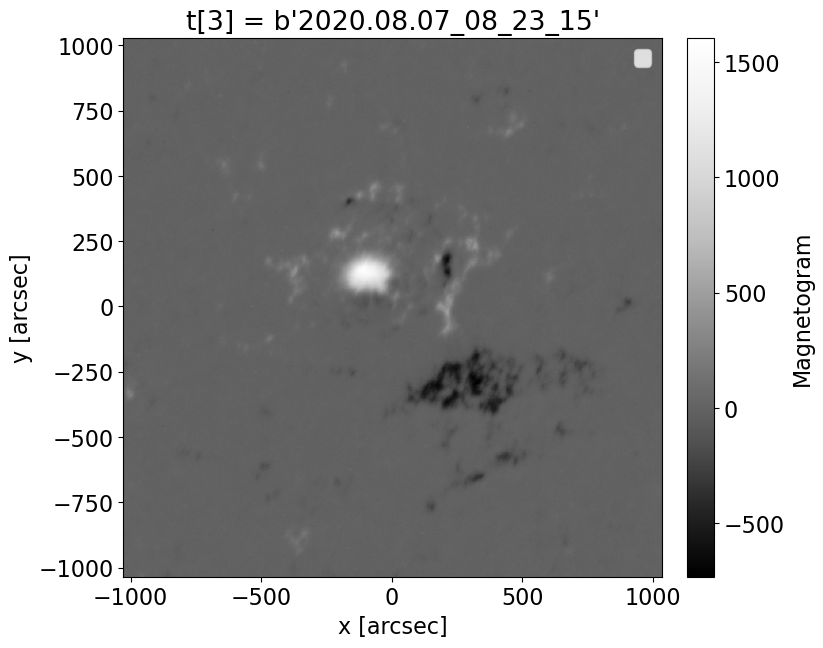

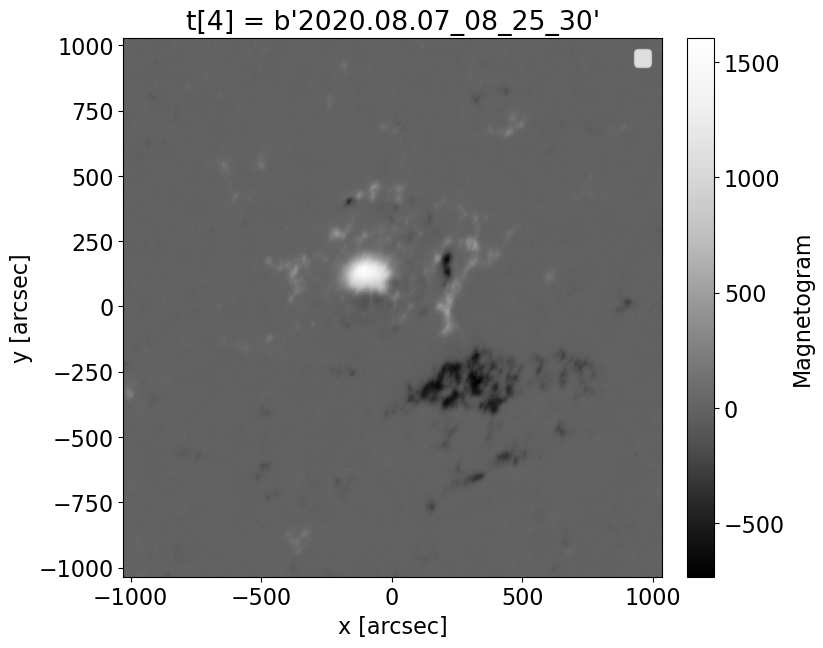

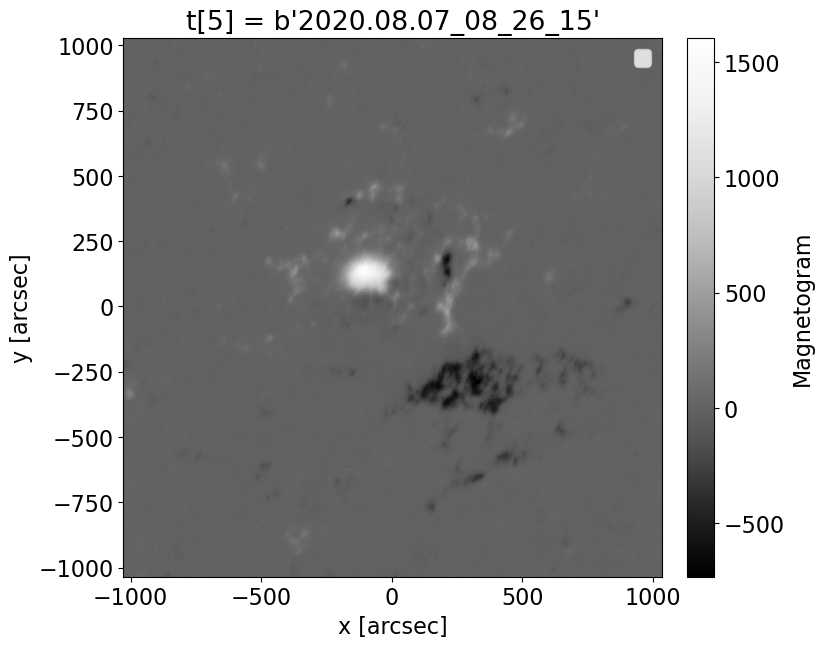

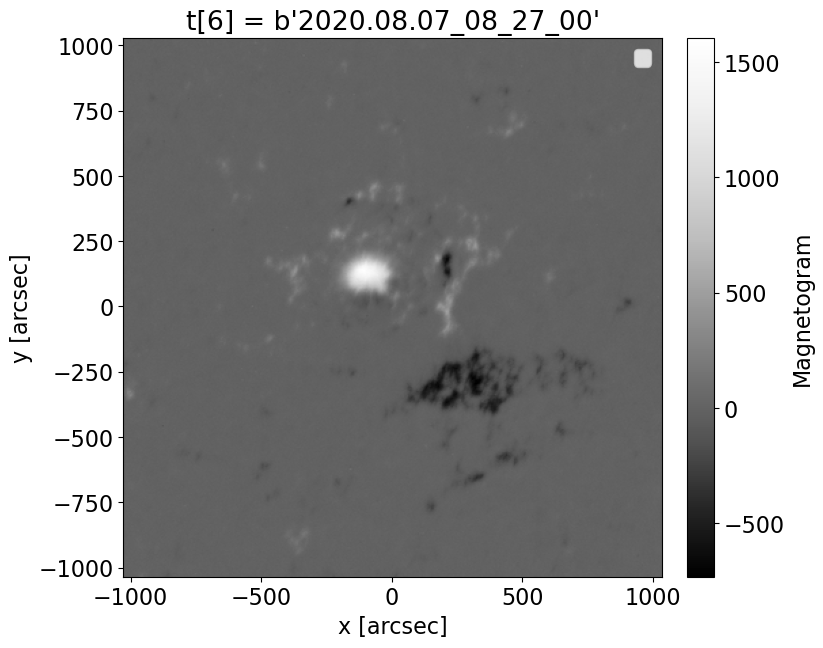

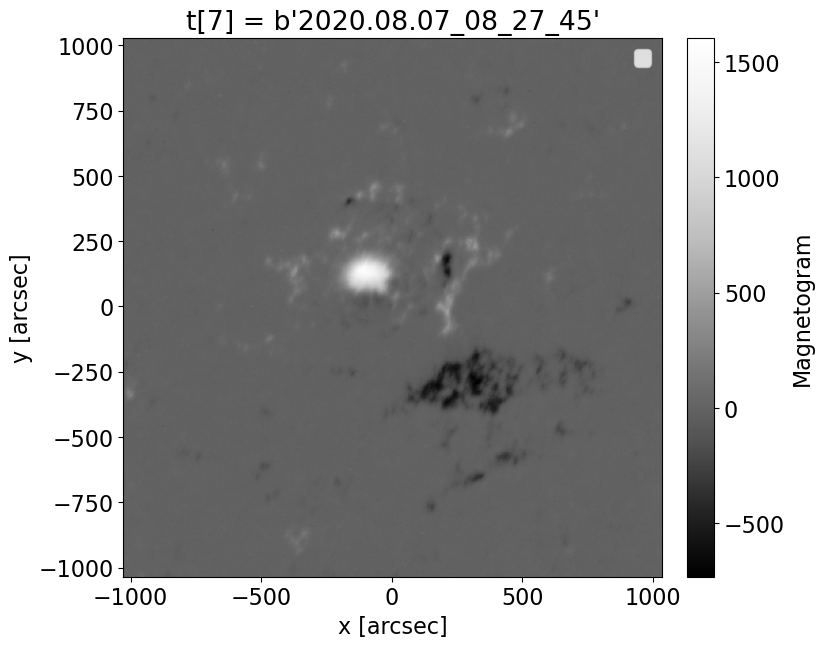

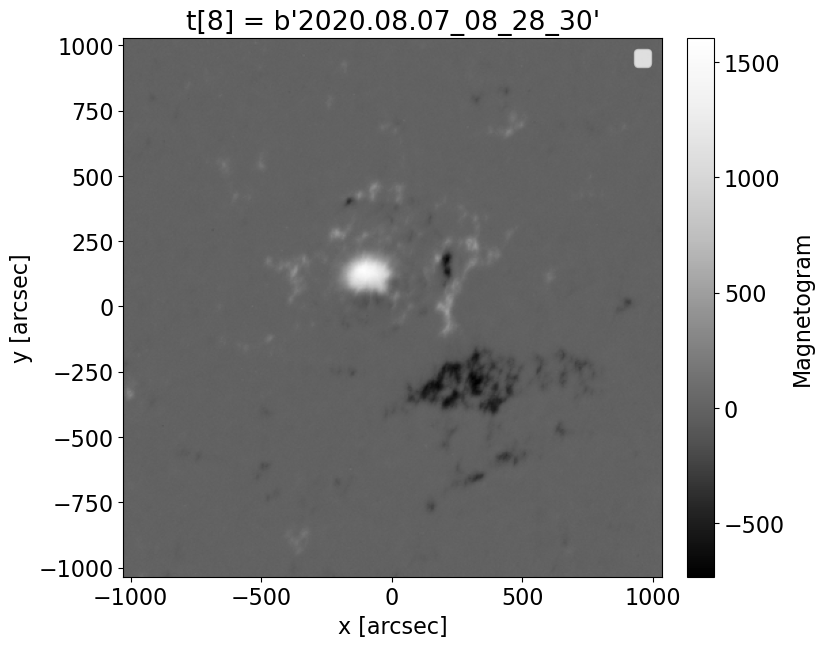

Error in callback <function flush_figures at 0x7f5e5cfdfa30> (for post_execute):


KeyboardInterrupt: 

In [ ]:
for t in range(len(SDOMHI_magnetogram["datentime"][:])):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_title(f"t[{t}] = {SDOMHI_magnetogram['datentime'][t]}")
    magnetogram = ax.imshow(SDOMHI_magnetogram["magnetogram"][0, :].T, origin="lower", extent = [np.min(SDOMHI_magnetogram["x"][:]), np.max(SDOMHI_magnetogram["x"][:]), np.min(SDOMHI_magnetogram["y"][:]), np.max(SDOMHI_magnetogram["y"][:])])
    fig.colorbar(magnetogram, ax=ax, fraction=0.046, pad=0.04, label="Magnetogram")
    ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
    plt.savefig(f"figures/SDOHMI_magnetogram/magnetogram_{t:04d}.png")

## 02 Intensity maps

### 2.1 Subfield A and B

In [8]:
# for frame in range(time.size):
#     fig, ax = plt.subplots(1, 3, figsize = (20, 6))
#     fig.suptitle(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     fig.supxlabel("x [arcsec]"); fig.supylabel("y [arcsec]")

#     im_fov = ax[0].imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     fig.colorbar(im_fov, ax=ax[0], fraction=0.046, pad=0.04)
    
#     ax[0].add_patch(Rectangle((sst4["x"][xy_A_min], sst4["y"][xy_A_min]), sst4["x"][xy_A_max]- sst4["x"][xy_A_min], sst4["y"][xy_A_max]- sst4["y"][xy_A_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0].add_patch(Rectangle((sst4["x"][xy_B_min], sst4["y"][xy_B_min]), sst4["x"][xy_B_max]- sst4["x"][xy_B_min], sst4["y"][xy_B_max]- sst4["y"][xy_B_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0].text(sst4["x"][xy_A_max] - 1.5, sst4["y"][xy_A_max] - 1.5, "A", color="red", fontsize = 14)
#     ax[0].text(sst4["x"][xy_B_max] - 1.5, sst4["y"][xy_B_max] - 1.5, "B", color="red", fontsize = 14)

#     A = ax[1].imshow(subfield_A[frame, line_core_idx], origin="lower", vmin = subfield_A.min(), vmax = subfield_A.max(), extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(A, ax=ax[1], fraction=0.046, pad=0.04)
#     ax[1].text(sst4["x"][xy_A_max] - .5, sst4["y"][xy_A_max] - .5, "A", color="white", fontsize = 24)

#     B = ax[2].imshow(subfield_B[frame, line_core_idx], origin="lower", vmin = subfield_B.min(), vmax = subfield_B.max(), extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     fig.colorbar(B, ax=ax[2], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[2].text(sst4["x"][xy_B_max] - .5, sst4["y"][xy_B_max] - .5, "B", color="white", fontsize = 24)
#     plt.tight_layout()
#     plt.savefig(f"figures/intensity_subfields/intensity_{frame:04d}.png")

### 2.2 Subfield A, B and C

In [9]:
# for frame in range(time.size):
#     fig, ax = plt.subplots(2, 2, figsize = (18, 18), constrained_layout=True)
#     fig.suptitle(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     fig.supxlabel("x [arcsec]"); fig.supylabel("y [arcsec]")

#     im_fov = ax[0, 0].imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_A_min], sst4["y"][xy_A_min]), sst4["x"][xy_A_max]- sst4["x"][xy_A_min], sst4["y"][xy_A_max]- sst4["y"][xy_A_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_B_min], sst4["y"][xy_B_min]), sst4["x"][xy_B_max]- sst4["x"][xy_B_min], sst4["y"][xy_B_max]- sst4["y"][xy_B_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_C_min], sst4["y"][xy_C_min]), sst4["x"][xy_C_max]- sst4["x"][xy_C_min], sst4["y"][xy_C_max]- sst4["y"][xy_C_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].text(sst4["x"][xy_A_max] - 1.5, sst4["y"][xy_A_max] - 1.5, "A", color="red", fontsize = 14)
#     ax[0, 0].text(sst4["x"][xy_B_max] - 1.5, sst4["y"][xy_B_max] - 1.5, "B", color="red", fontsize = 14)
#     ax[0, 0].text(sst4["x"][xy_C_max] - 1.5, sst4["y"][xy_C_max] - 1.5, "C", color="red", fontsize = 14)

#     A = ax[0, 1].imshow(subfield_A[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(A, ax=ax[0, 1], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[0, 1].text(sst4["x"][xy_A_max] - .5, sst4["y"][xy_A_max] - .5, "A", color="white", fontsize = 24)

#     B = ax[1, 0].imshow(subfield_B[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     ax[1, 0].text(sst4["x"][xy_B_max] - .5, sst4["y"][xy_B_max] - .5, "B", color="white", fontsize = 24)

#     C = ax[1, 1].imshow(subfield_C[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_C), np.max(x_subfield_C), np.min(y_subfield_C), np.max(y_subfield_C)])
#     fig.colorbar(C, ax=ax[1, 1], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[1, 1].text(sst4["x"][xy_C_max] - .5, sst4["y"][xy_C_max] - .5, "C", color="white", fontsize = 24)

# #     plt.tight_layout()
#     plt.savefig(f"figures/intensity_A_B_C/intensity_A_B_C_{frame:04d}.png")

### 2.3 Intensity masking

In [108]:
cut_off_intensity = intensity.max() / 2


def intensity_matrix(intensity, cut_off_intensity):
    """
    Create a mask of the intensity matrix where the intensity is above the cut-off value.
    """
    return np.where(intensity > cut_off_intensity, 1, 0)

In [12]:
# intensity_mask_A = intensity_matrix(subfield_A[:, line_core_idx, :], cut_off_intensity)
# intensity_mask_B = intensity_matrix(subfield_B[:, line_core_idx, :], cut_off_intensity)
# intensity_mask_C = intensity_matrix(subfield_C[:, line_core_idx, :], cut_off_intensity)

# np.save("intensity_mask_A.npy", intensity_mask_A)
# np.save("intensity_mask_B.npy", intensity_mask_B)
# np.save("intensity_mask_C.npy", intensity_mask_C)

In [13]:
intensity_mask_A = np.load("intensity_mask_A.npy")
intensity_mask_B = np.load("intensity_mask_B.npy")
intensity_mask_C = np.load("intensity_mask_C.npy")

## 03 Curve fit

### 3.1 Fitting Voigt to line profiles

In [109]:
def _voigt(x, amplitude, center, sigma, gamma, background):
    z = ((x - center) + 1j * gamma) / (sigma * np.sqrt(2))
    return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background

In [110]:
def _fit_voigt(x_data, y_data, nump, thr):
    # Create the interpolator using linear interpolation
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    x_interpolated = np.linspace(x_data.min(), x_data.max(), nump)
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                             # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               # Center of the dip

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")
    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component
    gamm_guess = sigma_guess          # Width of the Lorentzian component

    # Initial guesses for curve fitting parameters
    initial_guesses = [amplitude_guess, mean_guess, sigma_guess, gamm_guess, background_level_guess]

    # Fit the Voigt profile
    popt, pcov = curve_fit(_voigt, x_interpolated, y_interpolated, p0=initial_guesses, maxfev=5000)
    return x_interpolated, _voigt(x_interpolated, *popt)

### 3.2 Fitting Gaussian to line profiles

In [111]:
def _gaussian(x, amplitude, mean, sigma, background):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2)) + background

In [112]:
def _fit_gaussian(x_data, y_data, nump, thr):
    # Create the interpolator using linear interpolation
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    x_interpolated = np.linspace(x_data.min(), x_data.max(), nump)
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                  # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")

    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component

    # Initial guesses for curve fitting parameters
    initial_guesses = [amplitude_guess, mean_guess, sigma_guess, background_level_guess]

    # Fit the Gaussian profile
    popt, pcov = curve_fit(_gaussian, x_interpolated, y_interpolated, p0=initial_guesses, maxfev=5000)
    return x_interpolated, _gaussian(x_interpolated, *popt)

## 04 Average intensity profiles

### 4.1 Comparison betwewen Gaussian and Voigt profiles

Voigt fit time: 0.0239 s
Gaussian fit time: 0.0025 s


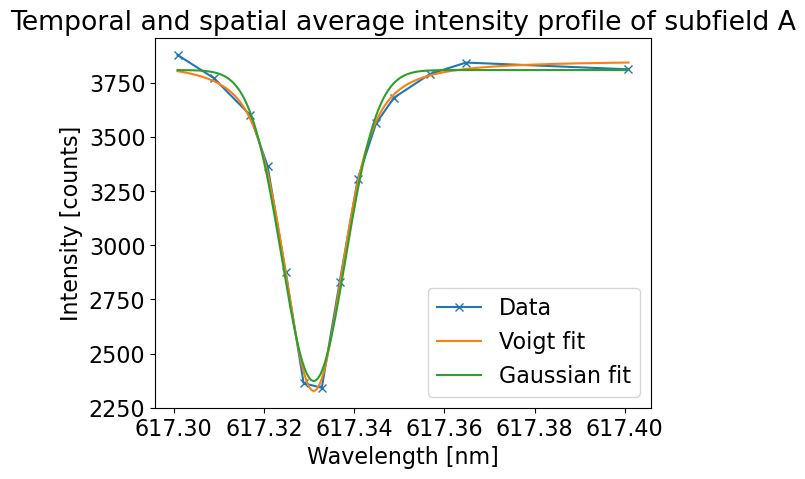

In [113]:
A_intensity_avg = np.average(subfield_A, axis=(0, 2, 3))
A_voigt_t0 = tt.time()
x_voigt, A_voigt_avg = _fit_voigt(wavelength, A_intensity_avg, nump = 1000, thr = 5)
A_voigt_tf = tt.time() 
print(f"Voigt fit time: {A_voigt_tf - A_voigt_t0:.4f} s")

A_gaussian_t0 = tt.time()
x_gaussian, A_gaussian_avg = _fit_gaussian(wavelength, A_intensity_avg, nump = 1000, thr = 5)
A_gaussian_tf = tt.time()
print(f"Gaussian fit time: {A_gaussian_tf - A_gaussian_t0:.4f} s")


plt.plot(wavelength, A_intensity_avg, marker = "x", label="Data")
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.plot(x_gaussian, A_gaussian_avg, label="Gaussian fit")
plt.title("Temporal and spatial average intensity profile of subfield A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

Voigt fit time: 0.0372 s
Gaussian fit time: 0.0023 s


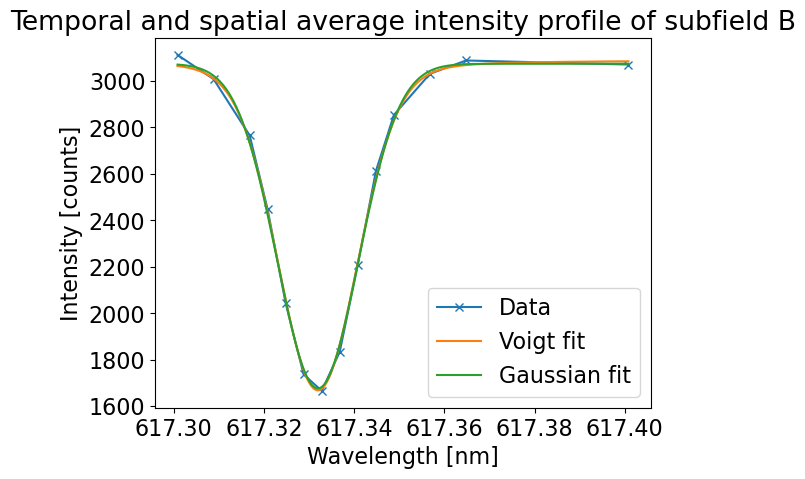

In [20]:
B_intensity_avg = np.average(subfield_B, axis=(0, 2, 3))

B_voigt_t0 = tt.time()
x_voigt, B_voigt_avg = _fit_voigt(wavelength, B_intensity_avg, nump = 1000, thr = 5)
B_voigt_tf = tt.time()
print(f"Voigt fit time: {B_voigt_tf - B_voigt_t0:.4f} s")

B_gaussian_t0 = tt.time()
x_gaussian, B_gaussian_avg = _fit_gaussian(wavelength, B_intensity_avg, nump = 1000, thr = 5)
B_gaussian_tf = tt.time()
print(f"Gaussian fit time: {B_gaussian_tf - B_gaussian_t0:.4f} s")

plt.plot(wavelength, B_intensity_avg, marker = "x", label="Data")
plt.plot(x_voigt, B_voigt_avg, label="Voigt fit")
plt.plot(x_gaussian, B_gaussian_avg, label="Gaussian fit")
plt.title("Temporal and spatial average intensity profile of subfield B")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

Voigt fit time: 0.0372 s
Gaussian fit time: 0.0028 s


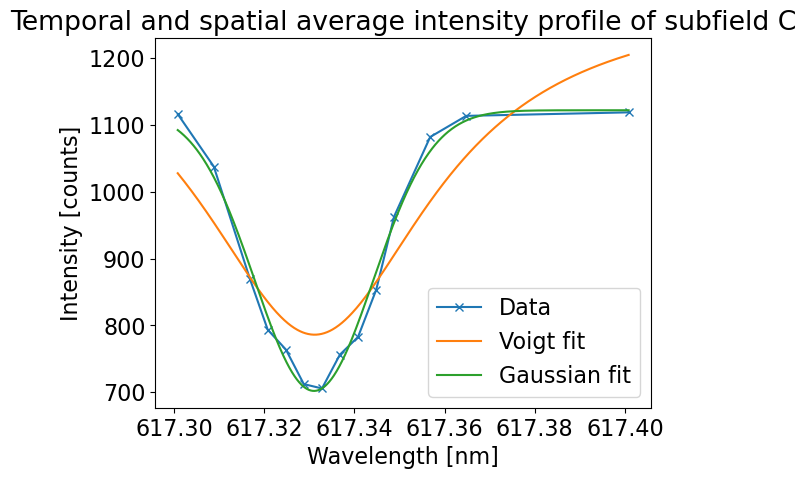

In [22]:
C_intensity_avg = np.average(subfield_C, axis=(0, 2, 3))

C_voigt_t0 = tt.time()
x_voigt, C_voigt_avg = _fit_voigt(wavelength, C_intensity_avg, nump = 1000, thr = 5)
C_voigt_tf = tt.time()
print(f"Voigt fit time: {B_voigt_tf - B_voigt_t0:.4f} s")

C_gaussian_t0 = tt.time()
x_gaussian, C_gaussian_avg = _fit_gaussian(wavelength, C_intensity_avg, nump = 1000, thr = 5)
C_gaussian_tf = tt.time()
print(f"Gaussian fit time: {C_gaussian_tf - C_gaussian_t0:.4f} s")

plt.plot(wavelength, C_intensity_avg, marker = "x", label="Data")
plt.plot(x_voigt, C_voigt_avg, label="Voigt fit")
plt.plot(x_gaussian, C_gaussian_avg, label="Gaussian fit")
plt.title("Temporal and spatial average intensity profile of subfield C")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

### 4.2 Temporal and spatially averaged intensity profile

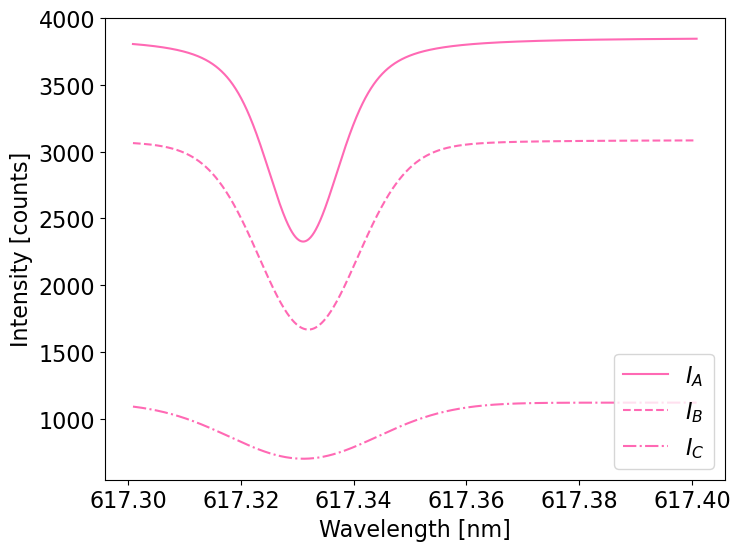

In [114]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(x_voigt, A_voigt_avg, label="$I_A$", color = "hotpink")
ax.plot(x_voigt, B_voigt_avg, label="$I_B$", color = "hotpink",  ls = "--")
ax.plot(x_gaussian, C_gaussian_avg, label="$I_C$", color = "hotpink",  ls = "-.")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [counts]")
ax.legend(loc = "lower right")
# plt.savefig("figures/temp_spat_avg_voigt_intensity_A_B_C.png")
plt.show()

### 4.2.1 Error analysis of temporally and spatially averaged intensity profile

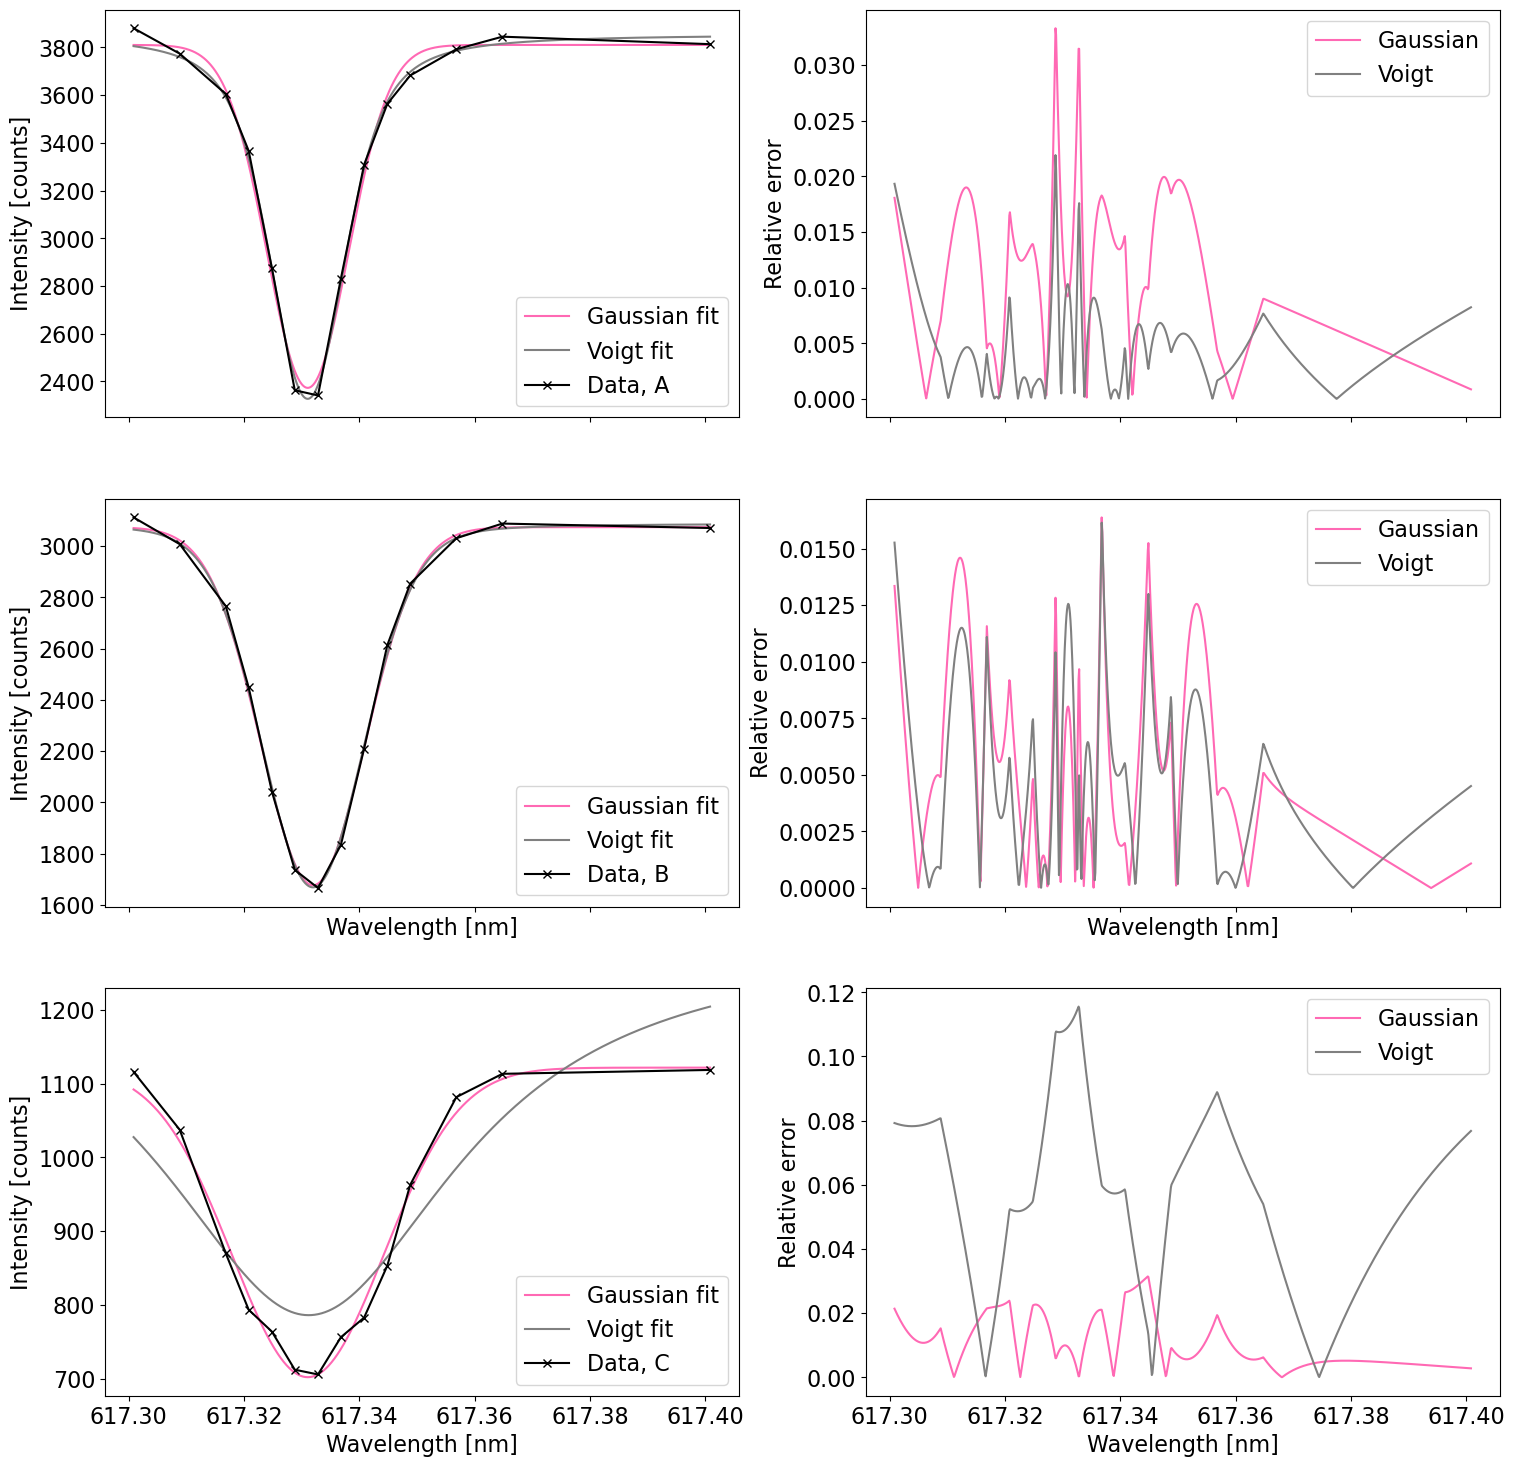

In [115]:
dataset = [np.average(subfield_A, axis = (0, 2, 3)), 
           np.average(subfield_B, axis = (0, 2, 3)), 
           np.average(subfield_C, axis = (0, 2, 3))]

dataname = ["A", "B", "C"]

fig, ax = plt.subplots(3, 2, sharex = True, figsize = (18, 18))
for i in range(len(dataset)):

    # Create the interpolator using linear interpolation
    y_data = dataset[i]
    x_data = wavelength
    x_interpolated = np.linspace(x_data.min(), x_data.max(), 1000)
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                             # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               # Center of the dip

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    thr = 5
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")
        continue
    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component
    gamma_guess = sigma_guess

    # gaussian
    initial_guesses_gauss = [amplitude_guess, mean_guess, sigma_guess, background_level_guess]
    popt_gauss, pcov_gauss = curve_fit(_gaussian, x_interpolated, y_interpolated, p0=initial_guesses_gauss, maxfev=5000)

    # voigt
    initial_guesses_voigt = [amplitude_guess, mean_guess, sigma_guess, gamma_guess, background_level_guess]
    popt_voigt, pcov_voigt = curve_fit(_voigt, x_interpolated, y_interpolated, p0=initial_guesses_voigt, maxfev=5000)

    abs_err_gauss = np.abs( _gaussian(x_interpolated, *popt_gauss) - y_interpolated ) / y_interpolated
    abs_err_voigt = np.abs( _voigt(x_interpolated, *popt_voigt) - y_interpolated ) / y_interpolated

    ax[i, 0].plot(x_interpolated, _gaussian(x_interpolated, *popt_gauss), color = 'hotpink', ls = '-', label=f'Gaussian fit')
    ax[i, 0].plot(x_interpolated, _voigt(x_interpolated, *popt_voigt), color='gray', ls ='-', label=f'Voigt fit')
    ax[i, 0].plot(x_data, y_data, 'kx-', label=f'Data, {dataname[i]}')
    ax[i, 0].legend()

    ax[i, 1].plot(x_interpolated, abs_err_gauss, color = 'hotpink', ls = '-', label='Gaussian')
    ax[i, 1].plot(x_interpolated, abs_err_voigt, color = 'gray', ls = '-', label='Voigt')
    ax[i, 1].legend()

    if i > 0:
        ax[i, 0].set_xlabel("Wavelength [nm]")
        ax[i, 1].set_xlabel("Wavelength [nm]")
    ax[i, 0].set_ylabel("Intensity [counts]")
    ax[i, 1].set_ylabel("Relative error")

    # plt.savefig("figures/rel_err_gauss_voigt_A_B_C.png")
    
plt.show()

Peak intensity value, subfield A: 3829.9582386861193 counts
Peak intensity value, subfield B: 3069.9476772608564 counts
Peak intensity value, subfield B: 1117.5870635966621 counts
Difference in peak intensity values: 760.010561425263 counts
Difference in peak intensity values: 1952.3606136641943 counts


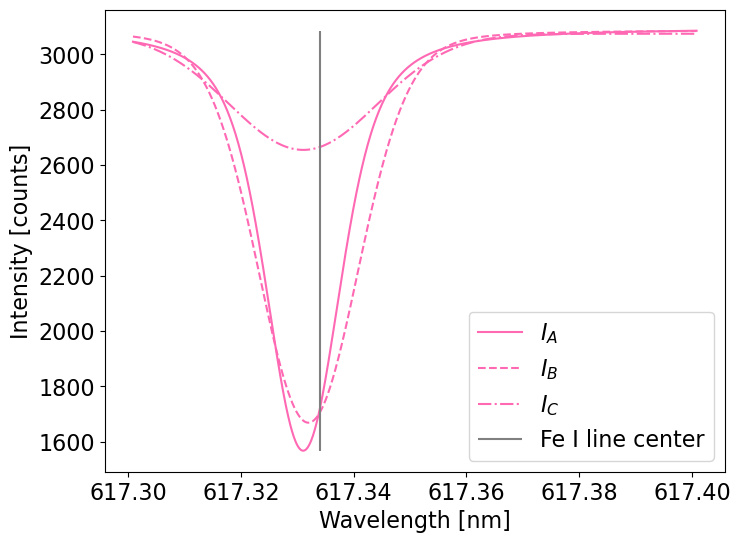

In [41]:
counts, bin_edges = np.histogram(A_voigt_avg, bins = 100)
max_count_index_A = np.argmax(counts)
peak_intensity_value_A = bin_edges[max_count_index_A]
print(f"Peak intensity value, subfield A: {peak_intensity_value_A} counts")

counts, bin_edges = np.histogram(B_voigt_avg, bins = 100)
max_count_index_B = np.argmax(counts)
peak_intensity_value_B = bin_edges[max_count_index_B]
print(f"Peak intensity value, subfield B: {peak_intensity_value_B} counts")

counts, bin_edges = np.histogram(C_gaussian_avg, bins = 100)
max_count_index_C = np.argmax(counts)
peak_intensity_value_C = bin_edges[max_count_index_C]
print(f"Peak intensity value, subfield B: {peak_intensity_value_C} counts")

diff_AB = np.abs(peak_intensity_value_A - peak_intensity_value_B)
print(f"Difference in peak intensity values: {diff_AB} counts")

diff_CB = np.abs(peak_intensity_value_C - peak_intensity_value_B)
print(f"Difference in peak intensity values: {diff_CB} counts")

fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(x_voigt, A_voigt_avg - diff_AB, label="$I_A$", color = "hotpink")
ax.plot(x_voigt, B_voigt_avg, label="$I_B$", color = "hotpink", ls = "--")
ax.plot(x_gaussian, C_gaussian_avg + diff_CB, label="$I_C$", color = "hotpink", ls = "-.")
ax.vlines(FeI_obs, A_voigt_avg.min() - diff_AB, A_voigt_avg.max() - diff_AB, color = "gray", ls = "solid", label="Fe I line center")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [counts]")
ax.legend(loc = "lower right")
# plt.savefig("figures/temp_spat_avg_voigt_intensity_scaled_A_B_C.png")
plt.show()

### 4.3 Spatially averaged intensity profile (Gaussian)(Doppler maps)

In [116]:
thr = 8
nump = 1000
intensity_avg_A_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_A[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_A_gaussian[t] = y_gauss

In [117]:
thr = 8
nump = 1000
intensity_avg_B_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_B[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_B_gaussian[t] = y_gauss

In [118]:
thr = 8
nump = 1000
intensity_avg_C_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_C[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_C_gaussian[t] = y_gauss

In [122]:
thr = 8
nump = 1000
intensity_avg_C_voigt = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_C[t, :], axis = (1, 2))
    x_voigt, y_voigt = _fit_voigt(wavelength, y_data, nump, thr)
    intensity_avg_C_voigt[t] = y_voigt

/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


In [123]:
thr = 8
nump = 1000
intensity_avg_FOV_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(intensity[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_FOV_gaussian[t] = y_gauss

## 05 Dopplergram

In [124]:
def create_doppler_maps(data, intensity_avg, time_step, nump, thr):
    d_map = np.zeros((data.shape[2], data.shape[3]))
    for x_idx in range(data.shape[3]):
        for y_idx in range(data.shape[2]):
            # pixel intensity
            pixel_intensity = data[time_step, :, y_idx, x_idx]
            x_gaussian, y_gaussian = _fit_gaussian(wavelength, pixel_intensity, nump, thr)
            min_idx_pixel = np.argmin(y_gaussian)

            # finding line core of spatially averaged intensity
            min_idx_avg = np.argmin(intensity_avg[time_step])

            delta_lambda = x_gaussian[min_idx_pixel]*units.nm - x_gaussian[min_idx_avg]*units.nm
            v = delta_lambda.to(units.m) / (x_gaussian[min_idx_avg]*units.nm).to(units.m) * c
            d_map[y_idx, x_idx] = (v.to(units.km/units.s)).value

    return d_map

### 5.1 Saving data cube of Doppler maps as .npy

In [91]:
# doppler_cube_A = np.zeros((time.size, subfield_A.shape[2], subfield_A.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_A[t] = create_doppler_maps(subfield_A, xy_A_min, xy_A_max, intensity_avg_A_gaussian, time_step=t)
# np.save("doppler_cube_A.npy", doppler_cube_A)

In [92]:
# doppler_cube_B = np.zeros((time.size, subfield_B.shape[2], subfield_B.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_B[t] = create_doppler_maps(subfield_B, intensity_avg_B_gaussian, time_step=t, nump=1000, thr=15)
# np.save("doppler_cube_B.npy", doppler_cube_B)

In [ ]:
# doppler_cube_C = np.zeros((time.size, subfield_C.shape[2], subfield_C.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_C[t] = create_doppler_maps(subfield_C, intensity_avg_C_voigt, time_step=t, nump=1000, thr=15)
# np.save("doppler_cube_C.npy", doppler_cube_C)

Time step: 0
Time step: 1
Time step: 2
Time step: 3
Time step: 4
Time step: 5
Time step: 6
Time step: 7
Time step: 8
Time step: 9
Time step: 10
Time step: 11
Time step: 12
Time step: 13
Time step: 14
Time step: 15
Time step: 16
Time step: 17
Time step: 18
Time step: 19
Time step: 20
Time step: 21
Time step: 22
Time step: 23
Time step: 24
Time step: 25
Time step: 26
Time step: 27
Time step: 28
Time step: 29
Time step: 30
Time step: 31


/mn/stornext/d20/RoCS/rebeccng/env/my_env/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Time step: 32
Time step: 33
Time step: 34
Time step: 35
Time step: 36
Time step: 37
Time step: 38
Time step: 39
Time step: 40
Time step: 41
Time step: 42
Time step: 43
Time step: 44
Time step: 45
Time step: 46
Time step: 47
Time step: 48
Time step: 49
Time step: 50
Time step: 51
Time step: 52
Time step: 53
Time step: 54
Time step: 55
Time step: 56


### 5.2 Loading Doppler cubes

In [126]:
doppler_cube_A = np.load("doppler_cube_A.npy")
doppler_cube_B = np.load("doppler_cube_B.npy")
doppler_cube_C = np.load("doppler_cube_C.npy")

In [127]:
print(np.min(doppler_cube_A), np.max(doppler_cube_A))
print(np.min(doppler_cube_B), np.max(doppler_cube_B))
print(np.min(doppler_cube_C), np.max(doppler_cube_C))

-3.158961969750567 2.624367980180884
-1.2149832063911414 1.6037783524439513
-14.67702330549566 1.8467777669141132


In [48]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     norm = mpl.colors.TwoSlopeNorm(vmin=doppler_cube_A.min(), vcenter=0, vmax=doppler_cube_A.max())
#     im = ax.imshow(doppler_cube_A[t, :, :], cmap = "seismic", norm = norm, origin="lower", extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(im, ax=ax, label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     ax.set_title(f"Subfield A, t[{t}] = {time_s[t]: .3f} s")
#     fig.tight_layout()
#     plt.savefig(f"figures/doppler_map_A/doppler_map_A_{t:04d}.png")

In [49]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     norm = mpl.colors.TwoSlopeNorm(vmin=doppler_cube_B.min(), vcenter=0, vmax=doppler_cube_B.max())
#     im = ax.imshow(doppler_cube_B[t, :, :], cmap = "seismic", norm = norm, origin="lower", extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     fig.colorbar(im, ax=ax, label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     ax.set_title(f"Subfield B, t[{t}] = {time_s[t]: .3f} s")
#     fig.tight_layout()
#     plt.savefig(f"figure/doppler_map_B/doppler_map_B_{t:04d}.png")

In [62]:

# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     norm = mpl.colors.TwoSlopeNorm(vmin=np.min(doppler_cube_C), vcenter=0, vmax=np.max(doppler_cube_C))
#     im = ax.imshow(doppler_cube_C[t, :, :], cmap="seismic", norm=norm, origin="lower", extent=[np.min(x_subfield_C), np.max(x_subfield_C), np.min(y_subfield_C), np.max(y_subfield_C)])
#     fig.colorbar(im, ax=ax, label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     ax.set_title(f"Subfield C, t[{t}] = {time_s[t]: .3f} s")
#     fig.tight_layout()
#     plt.savefig(f"figures/doppler_map_C/doppler_map_C_{t:04d}.png")

In [67]:
# for t in range(time.size):
#     fig, ax = plt.subplots(1, 3, figsize = (20, 6))
#     fig.supxlabel("x [arcsec]"); fig.supylabel("y [arcsec]")
#     fig.suptitle(f"t[{t}] = {time_s[t]: .3f} s")

#     norm_A = mpl.colors.TwoSlopeNorm(vmin=np.min(doppler_cube_A), vcenter=0, vmax=np.max(doppler_cube_A))
#     im_A = ax[0].imshow(doppler_cube_A[t, :, :], cmap="seismic", norm=norm_A, origin="lower", extent=[np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(im_A, ax=ax[0], label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax[0].set_title(f"Subfield A")
    
#     norm_B = mpl.colors.TwoSlopeNorm(vmin=np.min(doppler_cube_B), vcenter=0, vmax=np.max(doppler_cube_B))
#     im_B = ax[1].imshow(doppler_cube_B[t, :, :], cmap="seismic", norm=norm_B, origin="lower", extent=[np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     fig.colorbar(im_B, ax=ax[1], label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax[1].set_title(f"Subfield B")

#     norm_C = mpl.colors.TwoSlopeNorm(vmin=np.min(doppler_cube_C), vcenter=0, vmax=np.max(doppler_cube_C))
#     im_C = ax[2].imshow(doppler_cube_C[t, :, :], cmap="seismic", norm=norm_C, origin="lower", extent=[np.min(x_subfield_C), np.max(x_subfield_C), np.min(y_subfield_C), np.max(y_subfield_C)])
#     fig.colorbar(im_C, ax=ax[2], label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax[2].set_title(f"Subfield C")

#     fig.tight_layout()
#     # plt.savefig(f"figures/doppler_map/doppler_map_{t:04d}.png")

### 5.2 Histogram of Doppler velocities

Text(0.02, 0.5, 'Occurrences')

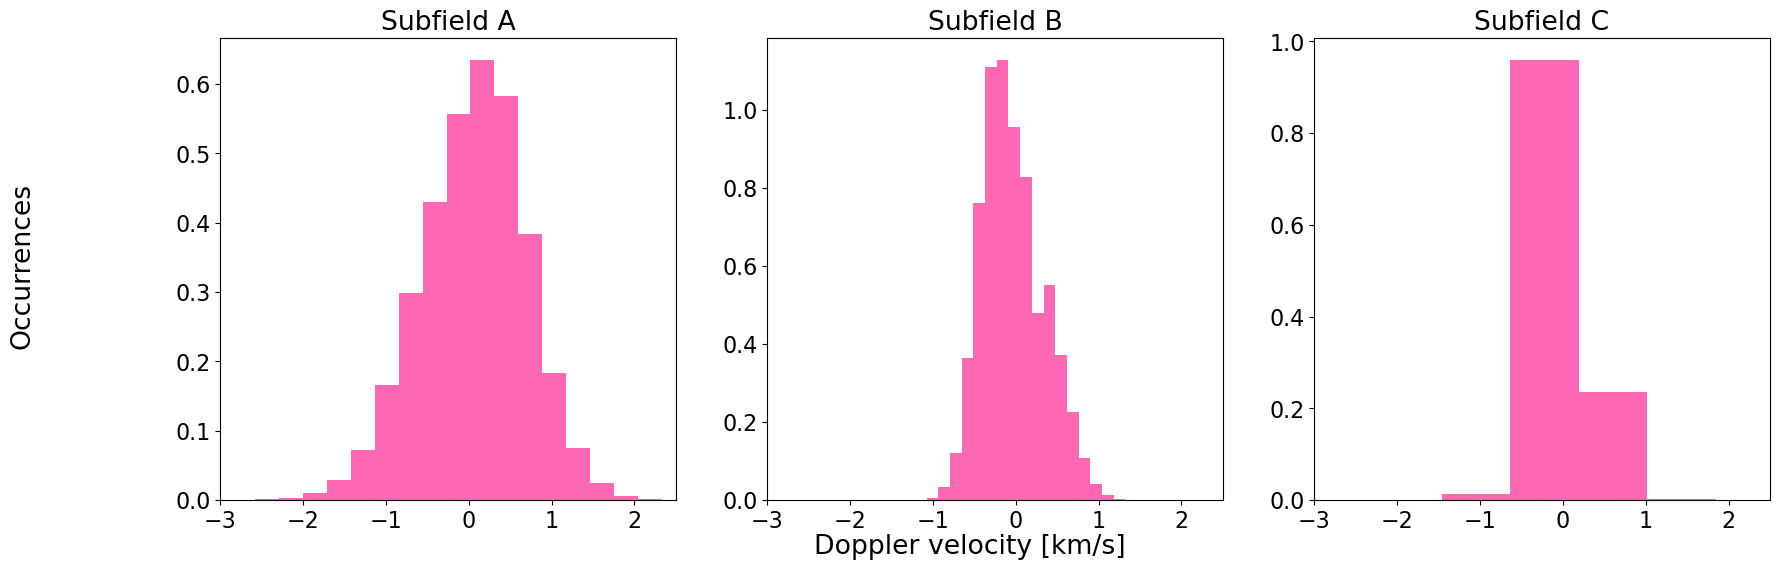

In [130]:
fig, ax = plt.subplots(1, 3, figsize = (20, 6))
bins = 20
counts_A, bin_edges_A = np.histogram(doppler_cube_A, bins=bins)
ax[0].hist(doppler_cube_A.flatten(), bins=bin_edges_A, label="Subfield A", density = True, histtype = 'bar',  color = "hotpink")


counts_B, bin_edges_B = np.histogram(doppler_cube_B, bins=bins)
ax[1].hist(doppler_cube_B.flatten(), bins=bin_edges_B, label="Subfield B", density=True, histtype='bar', color='hotpink')


counts_C, bin_edges_C = np.histogram(doppler_cube_C, bins=bins)
ax[2].hist(doppler_cube_C.flatten(), bins=bin_edges_C, label="Subfield C", density=True, histtype='bar', color='hotpink')

ax[0].set_xlim(-3, 2.5); ax[1].set_xlim(-3, 2.5); ax[2].set_xlim(-3, 2.5)
ax[0].set_title("Subfield A"), ax[1].set_title("Subfield B"), ax[2].set_title("Subfield C")
fig.supxlabel("Doppler velocity [km/s]")
fig.supylabel("Occurrences")
# plt.savefig("figures/doppler_histogram_A_B_C.png");

In [131]:
peak_index_A = np.argmax(counts_A)
peak_x_value_A = bin_edges_A[peak_index_A] + (bin_edges_A[peak_index_A + 1] - bin_edges_A[peak_index_A]) / 2
print(f"Peak value for subfield A: {peak_x_value_A} km/s")

peak_index_B = np.argmax(counts_B)
peak_x_value_B = bin_edges_B[peak_index_B] + (bin_edges_B[peak_index_B + 1] - bin_edges_B[peak_index_B]) / 2
print(f"Peak value for subfield B: {peak_x_value_B} km/s")

# Find the peak for Subfield C
peak_index_C = np.argmax(counts_C)
peak_x_value_C = bin_edges_C[peak_index_C] + (bin_edges_C[peak_index_C + 1] - bin_edges_C[peak_index_C]) / 2
print(f"Peak value for subfield C: {peak_x_value_C} km/s")

def rms(values):
    values = np.array(values)
    return np.sqrt(np.mean(values**2))

print("Subfield A")
print(f"Min: {np.min(doppler_cube_A): .3f}")
print(f"max: {np.max(doppler_cube_A): .3f}")
print(f"Mean: {np.mean(doppler_cube_A): .3f}")
print(f"std: {np.std(doppler_cube_A): .3f}")
print(f"RMS: {rms(doppler_cube_A): .3f}")

print("Subfield B")
print(f"Min: {np.min(doppler_cube_B): .3f}")
print(f"max: {np.max(doppler_cube_B): .3f}")
print(f"Mean: {np.mean(doppler_cube_B): .3f}")
print(f"std: {np.std(doppler_cube_B): .3f}")
print(f"RMS: {rms(doppler_cube_B): .3f}")

print("Subfield C")
print(f"Min: {np.min(doppler_cube_C): .3f}")
print(f"max: {np.max(doppler_cube_C): .3f}")
print(f"Mean: {np.mean(doppler_cube_C): .3f}")
print(f"std: {np.std(doppler_cube_C): .3f}")
print(f"RMS: {rms(doppler_cube_C): .3f}")

Peak value for subfield A: 0.16645275146001692 km/s
Peak value for subfield B: -0.1579476218279816 km/s
Peak value for subfield C: -0.21869736713710886 km/s
Subfield A
Min: -3.159
max:  2.624
Mean:  0.067
std:  0.635
RMS:  0.639
Subfield B
Min: -1.215
max:  1.604
Mean: -0.027
std:  0.365
RMS:  0.366
Subfield C
Min: -14.677
max:  1.847
Mean:  0.004
std:  0.256
RMS:  0.256


## 06 Equivalent width

### 6.1 Integration range

In [132]:
def int_range(intensity_data, wavelengths):
    counts, bin_edges = np.histogram(intensity_data, bins=30)
    max_count_index = np.argmax(counts)
    peak_intensity_value = bin_edges[max_count_index] #np.max(intensity_data) 


    line_center_idx = np.where(intensity_data == np.min(intensity_data))[0][0]
    line_center_wavelength = wavelengths[line_center_idx]

    cut_off_min = 0

    for wav in wavelengths[:line_center_idx]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_min = wav_idx
            break

    cut_off_max = 0
    for wav in wavelengths[line_center_idx:][::-1]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_max = wav_idx
            break

    return cut_off_min, cut_off_max, line_center_idx, peak_intensity_value

In [133]:
def calculate_ew_val(data, nump, thr):
    x_voigt, y_voigt = _fit_voigt(wavelength, data, nump, thr)

    cut_off_min, cut_off_max, line_center_idx, I_cont = int_range(y_voigt, x_voigt)
    ew = np.trapz(1 - y_voigt[cut_off_min:cut_off_max] / I_cont, x_voigt[cut_off_min:cut_off_max]) * units.nm

    return ew.to(units.mAA).value

### 6.2 Temporal evolution of spatially averaged equivalent width

/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


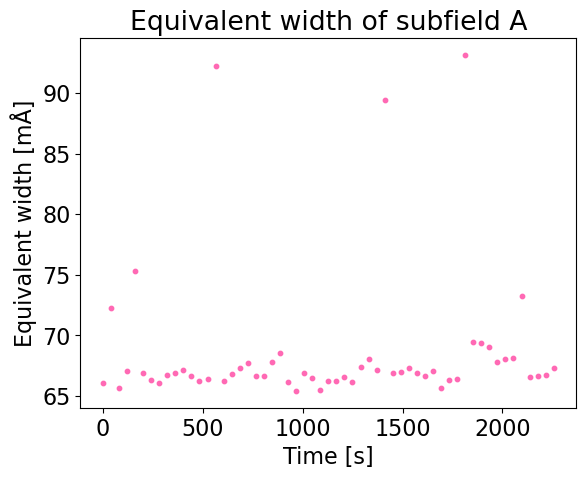

Average EW A: 68.56335768483186 mÅ
5.715013880306424
65.40636424169907 93.15001326664152
3.156993443132791 24.586655581809666


In [94]:
ew_vals_A = np.zeros(time.size)
for t in range(len(time)):
    spat_avg_A = np.average(subfield_A[t, :], axis = (1, 2))
    ew_vals_A[t] = calculate_ew_val(spat_avg_A, nump=1000, thr=15)
    
    plt.scatter(time_s[t], ew_vals_A[t], color = "hotpink", s = 10)
plt.xlabel("Time [s]")
plt.ylabel("Equivalent width [mÅ]")
plt.title("Equivalent width of subfield A")
# plt.savefig("figure/ew_A.png")
plt.show()

print(f"Average EW A: {np.mean(ew_vals_A)} mÅ")
print(np.std(ew_vals_A))
print(np.min(ew_vals_A), np.max(ew_vals_A))
print(np.mean(ew_vals_A) - np.min(ew_vals_A), np.max(ew_vals_A) - np.mean(ew_vals_A))

/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


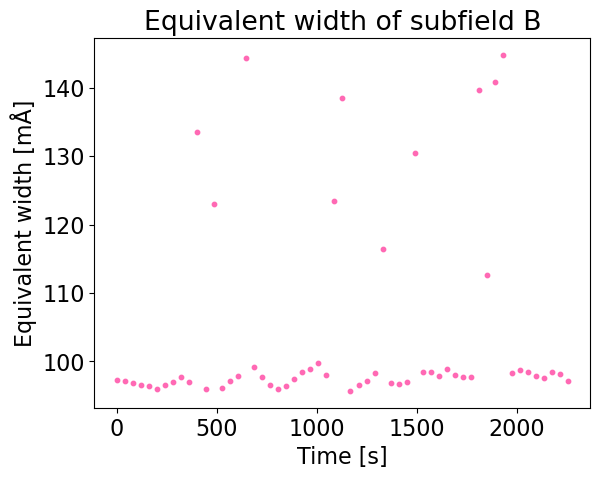

Average EW B: 104.04915586167402 mÅ
14.30909381894539
95.67178255803736 144.8097467309659
8.37737330363666 40.76059086929189


In [95]:
ew_vals_B = np.zeros(time.size)
for t in range(len(time)):
    spat_avg_B = np.average(subfield_B[t, :], axis = (1, 2))
    ew_vals_B[t] = calculate_ew_val(spat_avg_B, nump=1000, thr=15)
    #print(f"Time step: {t}, EW: {ew_vals_B[t]} mAA")
    plt.scatter(time_s[t], ew_vals_B[t], color = "hotpink", s = 10)
plt.xlabel("Time [s]")
plt.ylabel("Equivalent width [mÅ]")
plt.title("Equivalent width of subfield B")
# plt.savefig("figure/ew_B.png")
plt.show()
print(f"Average EW B: {np.mean(ew_vals_B)} mÅ")
print(np.std(ew_vals_B))
print(np.min(ew_vals_B), np.max(ew_vals_B))
print(np.mean(ew_vals_B) - np.min(ew_vals_B), np.max(ew_vals_B) - np.mean(ew_vals_B))

/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2345858/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


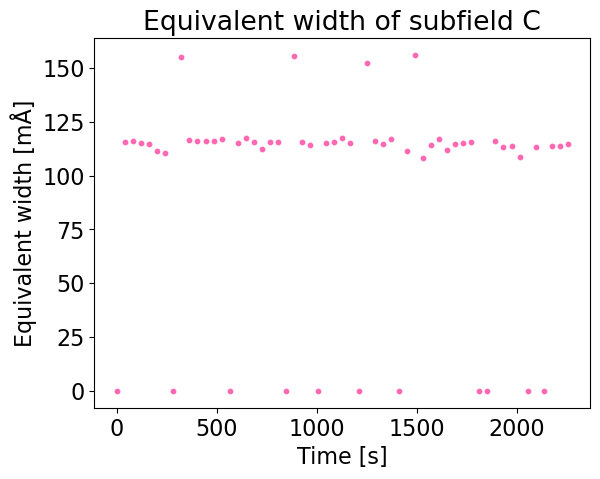

Average EW C: 95.24561404930225 mÅ
47.709120372003
0.0 156.01712205625927
95.24561404930225 60.77150800695702


In [136]:
ew_vals_C = np.zeros(time.size)
for t in range(len(time)):
    spat_avg_C = np.average(subfield_C[t, :], axis = (1, 2))
    ew_vals_C[t] = calculate_ew_val(spat_avg_C, nump=1000, thr=15)
    #print(f"Time step: {t}, EW: {ew_vals_B[t]} mAA")
    plt.scatter(time_s[t], ew_vals_C[t], color = "hotpink", s = 10)
plt.xlabel("Time [s]")
plt.ylabel("Equivalent width [mÅ]")
plt.title("Equivalent width of subfield C")
# plt.savefig("figure/ew_B.png")
plt.show()
print(f"Average EW C: {np.mean(ew_vals_C)} mÅ")
print(np.std(ew_vals_C))
print(np.min(ew_vals_C), np.max(ew_vals_C))
print(np.mean(ew_vals_C) - np.min(ew_vals_C), np.max(ew_vals_C) - np.mean(ew_vals_C))

### 6.3 Equivalent width maps for each time step

In [97]:
def create_ew_maps(data, time_step, nump, thr):
    ew_map = np.zeros((data.shape[2], data.shape[3]))
    for x_idx in range(data.shape[3]):
        for y_idx in range(data.shape[2]):
            # pixel intensity
            pixel_intensity = data[time_step, :, y_idx, x_idx]
            x_gaussian, y_gaussian = _fit_gaussian(wavelength, pixel_intensity, nump, thr)

            cut_off_min, cut_off_max, line_center_idx, I_cont = int_range(y_gaussian, x_gaussian)
            ew = np.trapz(1 - y_gaussian[cut_off_min:cut_off_max] / I_cont, x_gaussian[cut_off_min:cut_off_max]) * units.nm
            ew_map[y_idx, x_idx] = ew.to(units.mAA).value
    return ew_map

In [53]:
# ew_cube_A = np.zeros((time.size, subfield_A.shape[2], subfield_A.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     ew_map = create_ew_maps(subfield_A, t, nump=1000, thr=15)
#     ew_cube_A[t] = ew_map
# np.save("ew_cube_A.npy", ew_cube_A)

In [35]:
# ew_cube_B = np.zeros((time.size, subfield_B.shape[2], subfield_B.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     ew_map = create_ew_maps(subfield_B, t, nump=1000, thr=15)
#     ew_cube_B[t] = ew_map
# np.save("ew_cube_B.npy", ew_cube_B)

In [55]:
# ew_cube_C = np.zeros((time.size, subfield_C.shape[2], subfield_C.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     ew_map = create_ew_maps(subfield_C, t, nump=1000, thr=15)
#     ew_cube_C[t] = ew_map
# np.save("ew_cube_C.npy", ew_cube_C)

In [98]:
ew_cube_A = np.load("ew_cube_A.npy")
ew_cube_B = np.load("ew_cube_B.npy")
ew_cube_C = np.load("ew_cube_C.npy")

### 6.3.1 EW vs Doppler velocity, subfield A (no mask)

In [37]:
# for t in range(len(time)):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     x = ew_cube_A[t, :, :].flatten()
#     y = doppler_cube_A[t, :, :].flatten()

#     ax.scatter(x, y, alpha = .1, color = "hotpink")


#     coefficients = np.polyfit(x, y, 1)
#     slope, intercept = coefficients

#     fitted_line = slope * x + intercept

#     ax.plot(x, fitted_line, color='black', label='Linear fit')

#     ax.set_xlim(np.min(ew_cube_A), np.max(ew_cube_A))
#     ax.set_ylim(np.min(doppler_cube_A), np.max(doppler_cube_A))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}]={time_s[t]: .3f} s')
#     plt.legend(loc ='upper right')
#     plt.savefig(f"figures/ew_doppler_A/ew_doppler_A_{t:04d}.png")
#     #plt.show()

### 6.3.2 EW vs Doppler velocity, subfield A (w/ mask)

In [ ]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     x = ew_cube_A[t, :, :].flatten()
#     y = doppler_cube_A[t, :, :].flatten()
#     mask = intensity_mask_A[t].flatten()

#     # Split data based on intensity
#     x_high = x[mask == 1]
#     y_high = y[mask == 1]

#     x_low = x[mask == 0]
#     y_low = y[mask == 0]

#     # ax.scatter(x, y, alpha = .1, color = "hotpink")
#     ax.scatter(x[mask == 1], y[mask == 1], alpha=0.1, color='hotpink', label=r'$I > \frac{1}{2} I_{max}$')
#     ax.scatter(x[mask == 0], y[mask == 0], alpha=0.1, color='gray', label=r'$I \leq \frac{1}{2} I_{max}$')

#     # Linear fit for high-intensity points
#     if len(x_high) > 1:
#         slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
#         ax.plot(x_high, slope_high * x_high + intercept_high, color='deeppink', label='Linear fit (I > ½ max)')

#     # Linear fit for low-intensity points
#     if len(x_low) > 1:
#         slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
#         ax.plot(x_low, slope_low * x_low + intercept_low, color='dimgray', label='Linear fit (I ≤ ½ max)')

#     # Axes settings
#     ax.set_xlim(np.min(ew_cube_A), np.max(ew_cube_A))
#     ax.set_ylim(np.min(doppler_cube_A), np.max(doppler_cube_A))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}] = {time_s[t]:.3f} s')
#     ax.legend(loc='lower left')
#     plt.savefig(f"figures/ew_doppler_mask_A/ew_doppler_mask_A_{t:04d}.png")
#     plt.show()


### 6.3.3 EW vs. Doppler velocity, subfield B (no mask)

In [90]:
# for t in range(len(time)):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     x = ew_cube_B[t, :, :].flatten()
#     y = doppler_cube_B[t, :, :].flatten()

#     ax.scatter(x, y, alpha = .1, color = "hotpink")


#     coefficients = np.polyfit(x, y, 1)
#     slope, intercept = coefficients

#     fitted_line = slope * x + intercept

#     ax.plot(x, fitted_line, color='black', label='Linear fit')

#     ax.set_xlim(np.min(ew_cube_B), np.max(ew_cube_B))
#     ax.set_ylim(np.min(doppler_cube_B), np.max(doppler_cube_B))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}]={time_s[t]: .3f} s')
#     plt.legend(loc ='upper right')
#     #plt.savefig(f"figures/ew_doppler_A/ew_doppler_A_{t:04d}.png")
#     #plt.show()

### 6.3.4 EW vs. Doppler velocity, subfield B (w/ mask)

In [134]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")


#     x = ew_cube_B[t, :, :].flatten()
#     y = doppler_cube_B[t, :, :].flatten()
#     mask = intensity_mask_B[t].flatten()

#     # Split data based on intensity
#     x_high = x[mask == 1]
#     y_high = y[mask == 1]

#     x_low = x[mask == 0]
#     y_low = y[mask == 0]

#     ax.scatter(x[mask == 0], y[mask == 0], alpha=0.1, color='gray', label=r'$I \leq \frac{1}{2} I_{max}$')
#     ax.scatter(x[mask == 1], y[mask == 1], alpha=0.1, color='hotpink', label=r'$I > \frac{1}{2} I_{max}$')
    

#     # Linear fit for high-intensity points
#     if len(x_high) > 1:
#         slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
#         ax.plot(x_high, slope_high * x_high + intercept_high, color='deeppink', label='Linear fit (I > ½ max)')

#     # Linear fit for low-intensity points
#     if len(x_low) > 1:
#         slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
#         ax.plot(x_low, slope_low * x_low + intercept_low, color='dimgray', label='Linear fit (I ≤ ½ max)')

#     # Axes settings
#     ax.set_xlim(np.min(ew_cube_B), np.max(ew_cube_B))
#     ax.set_ylim(np.min(doppler_cube_B), np.max(doppler_cube_B))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}] = {time_s[t]:.3f} s')
#     ax.legend(loc='upper right')
#     plt.savefig(f"figures/ew_doppler_mask_B/ew_doppler_mask_B_{t:04d}.png")
#     plt.show()


### 6.3.5 EW vs. Doppler velocity, subfield C (no mask)

Time step: 0
Time step: 1
Time step: 2
Time step: 3
Time step: 4
Time step: 5
Time step: 6
Time step: 7
Time step: 8
Time step: 9
Time step: 10
Time step: 11
Time step: 12
Time step: 13
Time step: 14
Time step: 15
Time step: 16
Time step: 17
Time step: 18
Time step: 19


/tmp/ipykernel_2345858/2612200256.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize = (8, 6))


Time step: 20
Time step: 21
Time step: 22
Time step: 23
Time step: 24
Time step: 25
Time step: 26
Time step: 27
Time step: 28
Time step: 29
Time step: 30
Time step: 31
Time step: 32
Time step: 33
Time step: 34
Time step: 35
Time step: 36
Time step: 37
Time step: 38
Time step: 39
Time step: 40
Time step: 41
Time step: 42
Time step: 43
Time step: 44
Time step: 45
Time step: 46
Time step: 47
Time step: 48
Time step: 49
Time step: 50
Time step: 51
Time step: 52
Time step: 53
Time step: 54
Time step: 55
Time step: 56


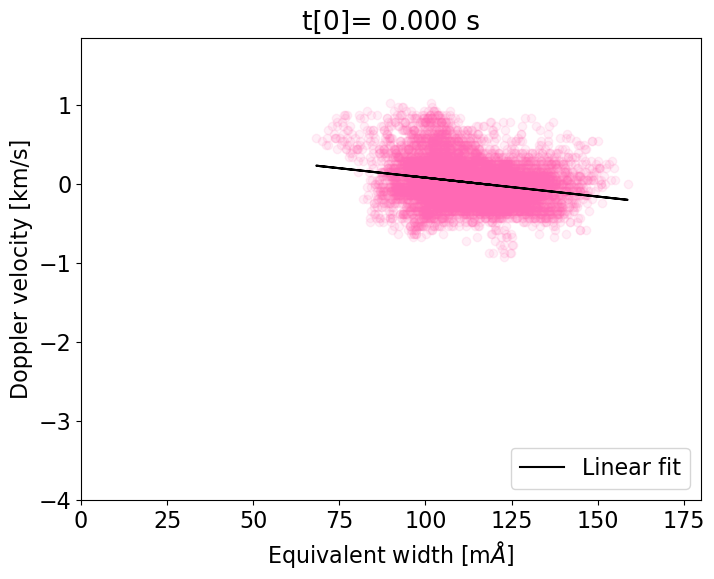

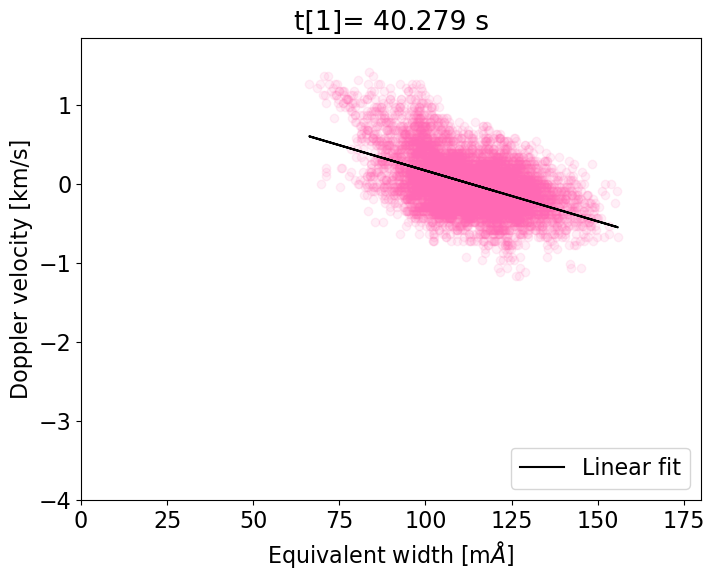

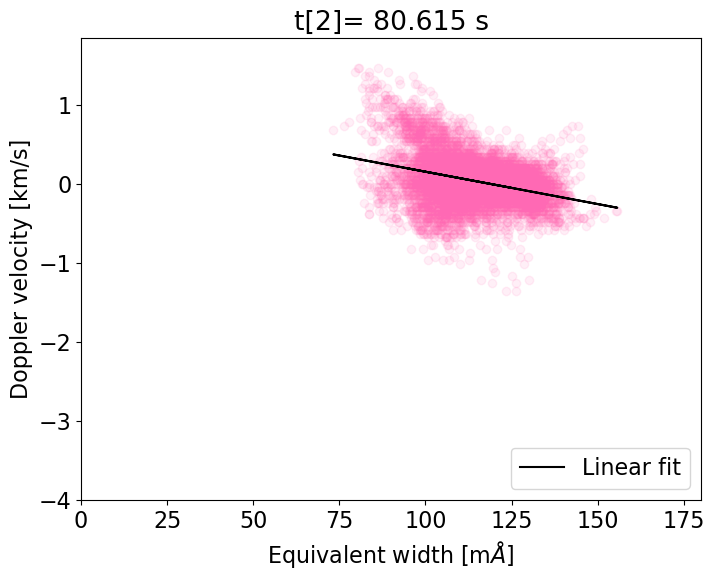

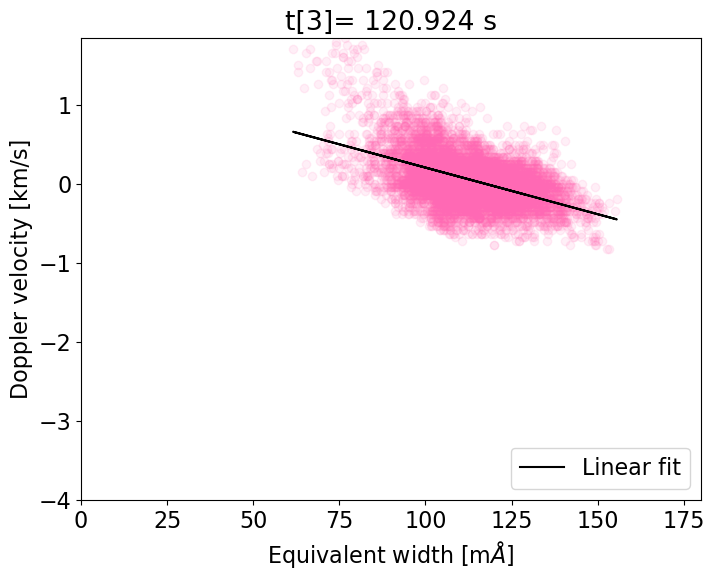

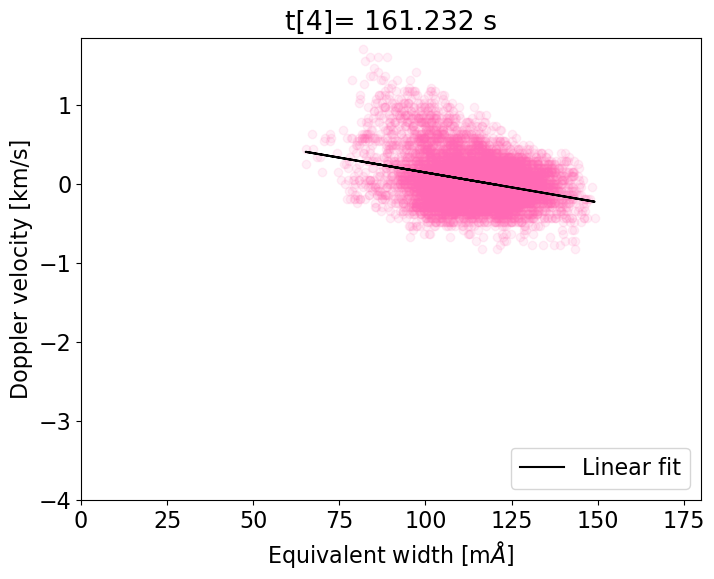

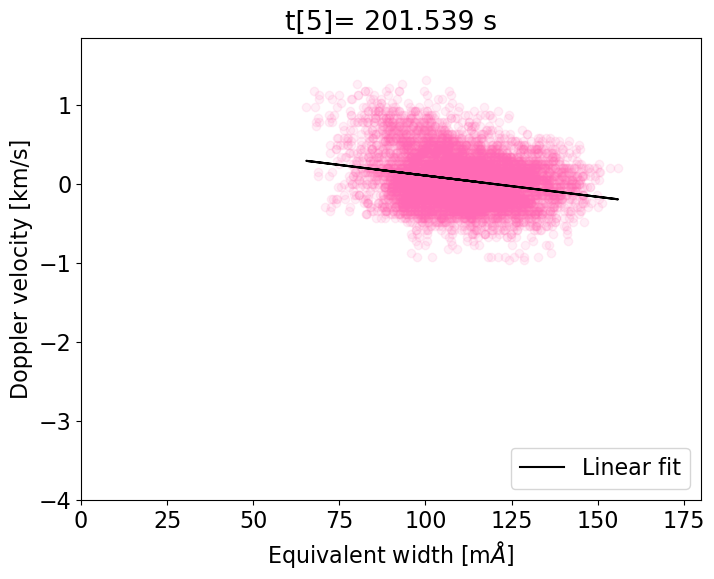

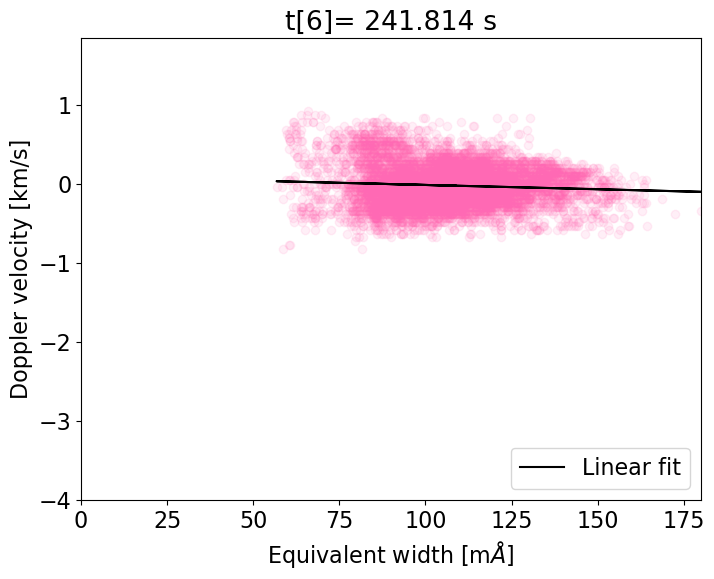

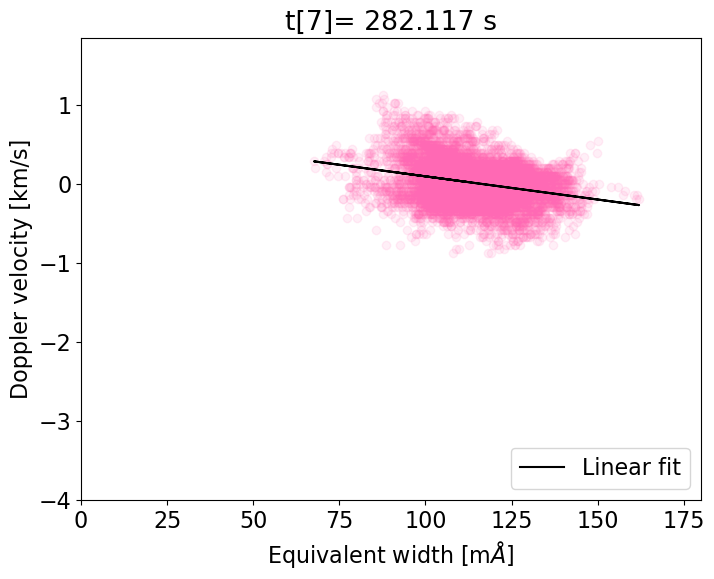

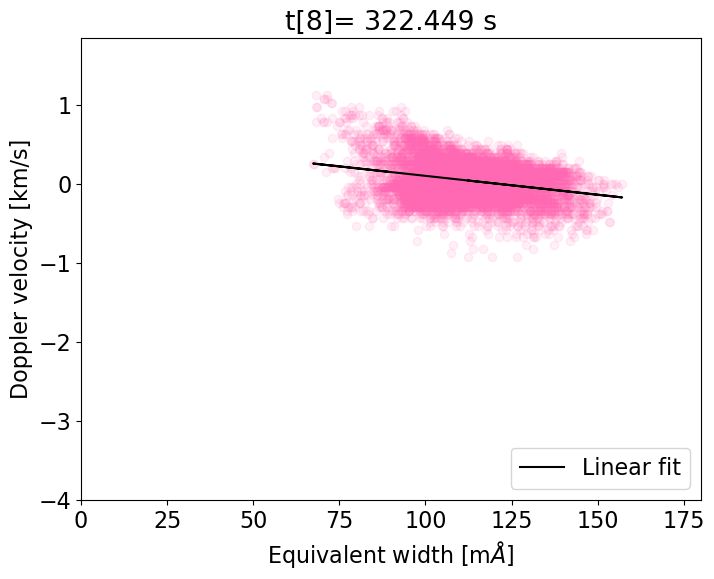

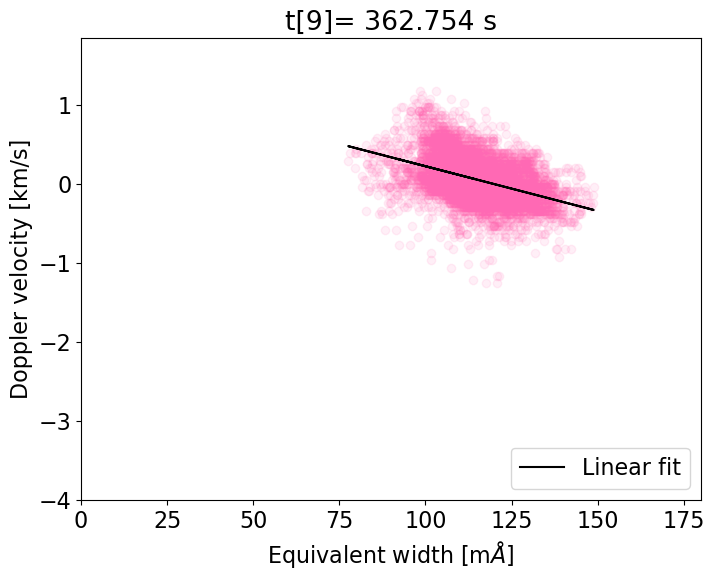

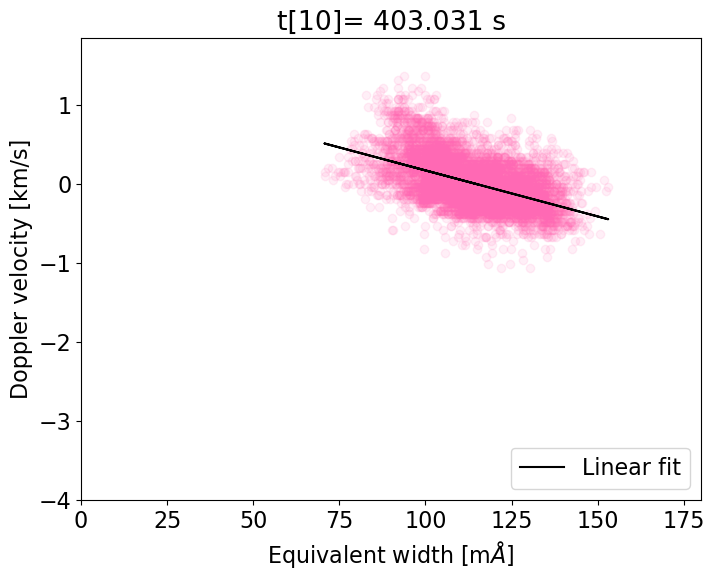

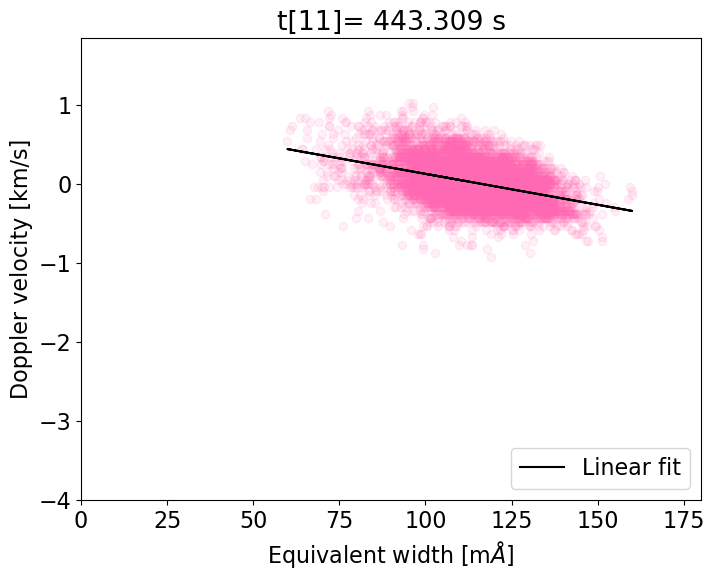

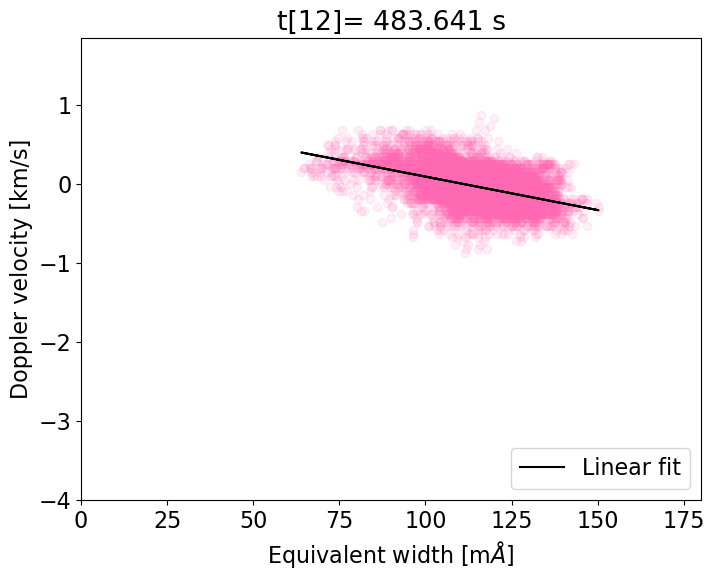

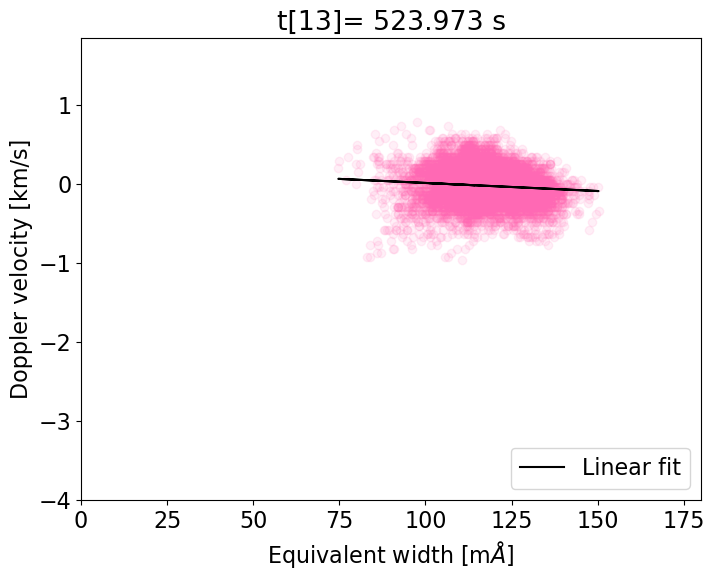

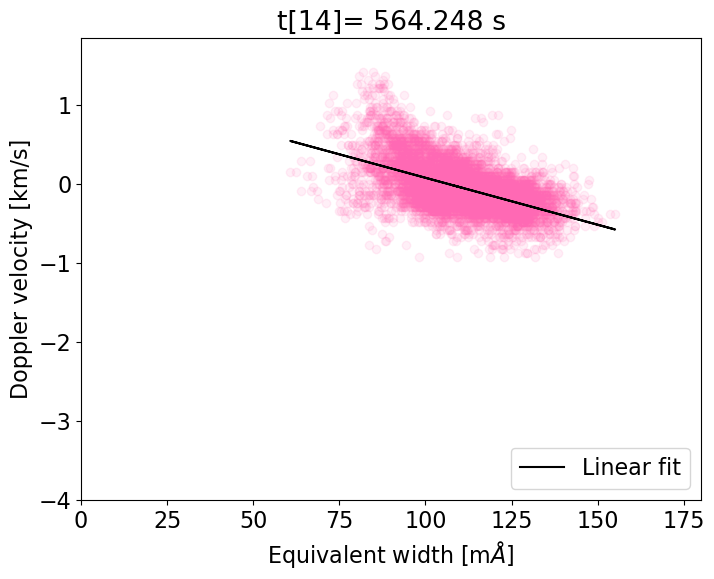

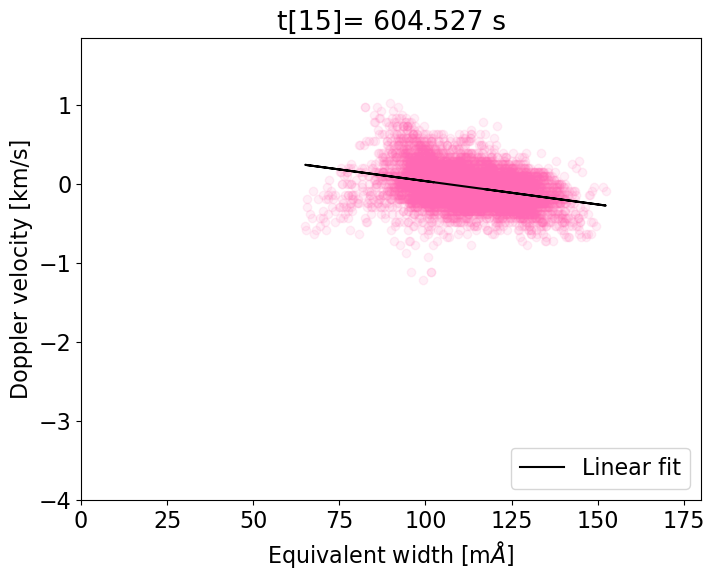

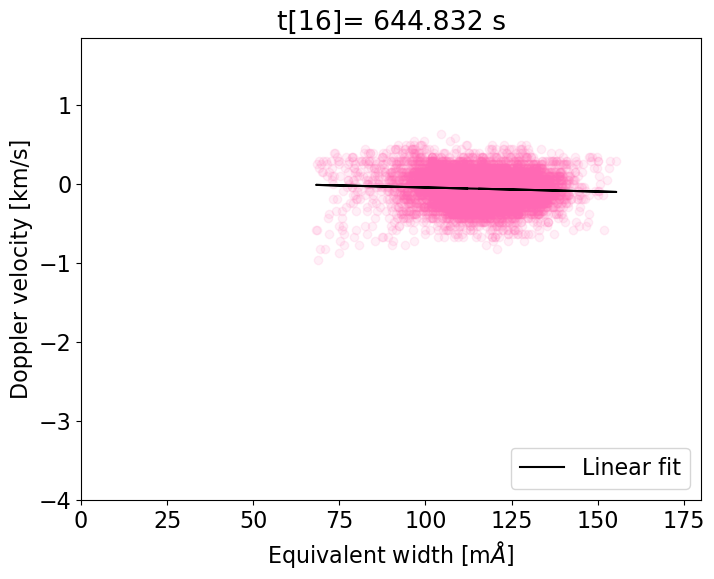

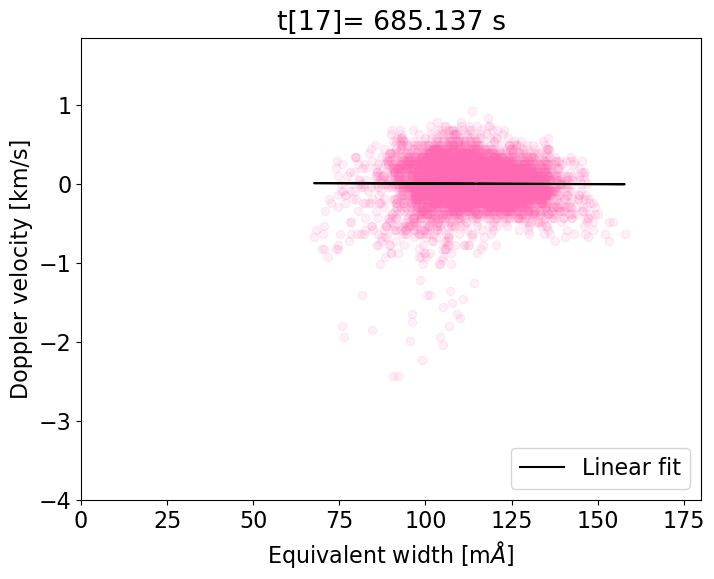

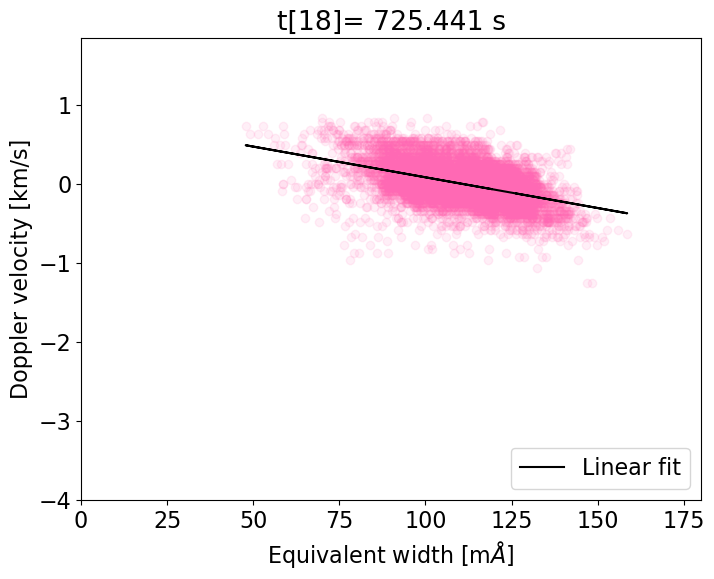

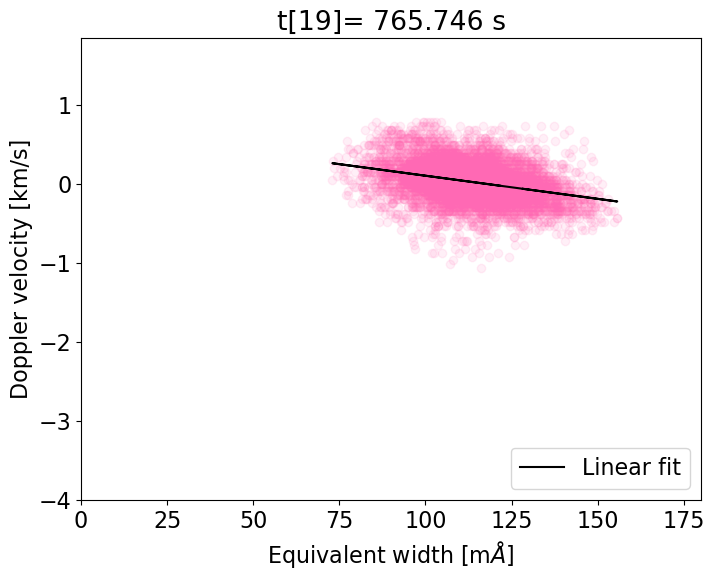

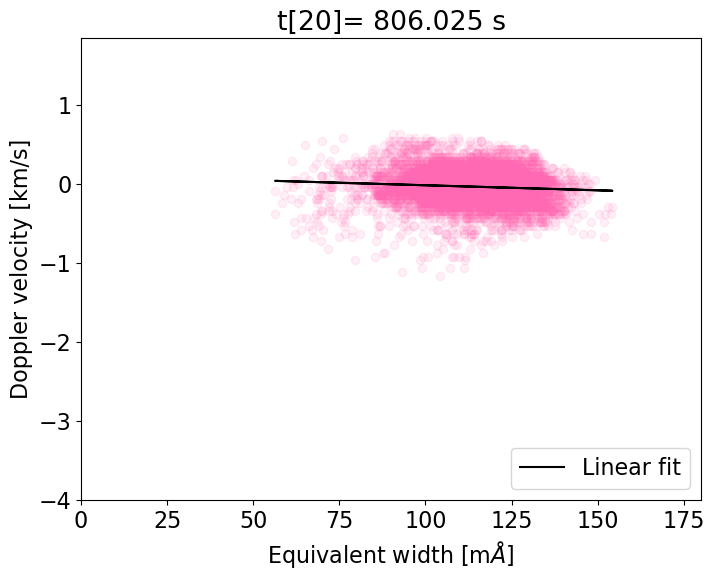

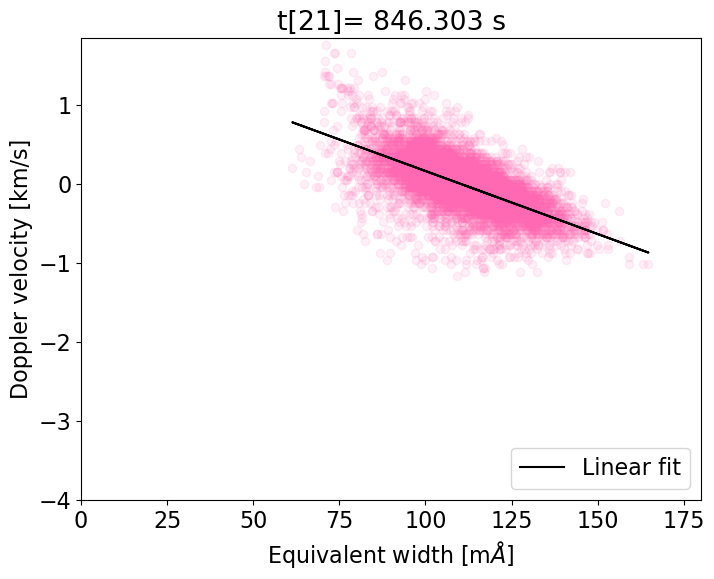

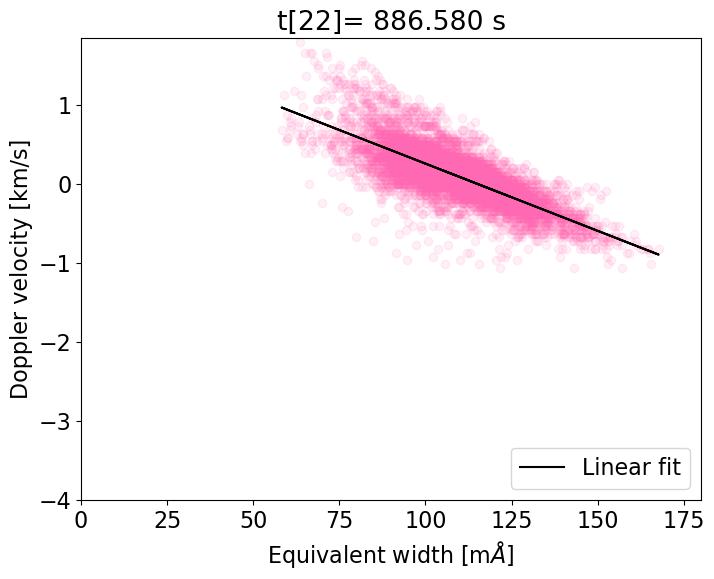

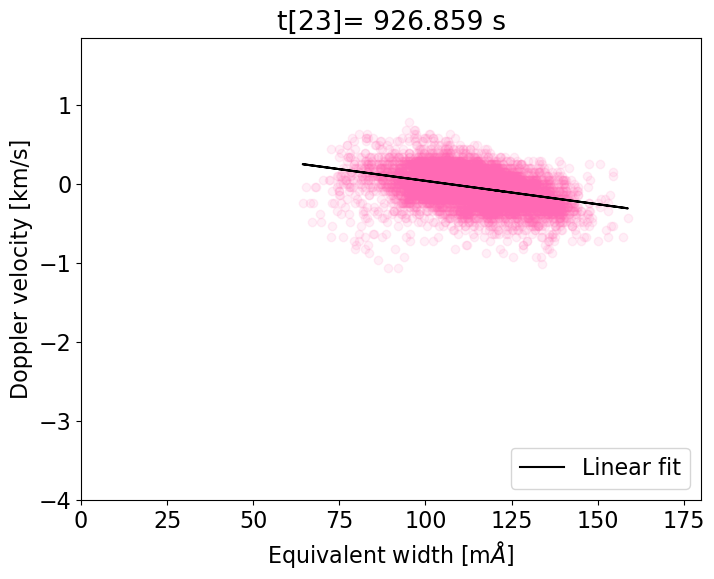

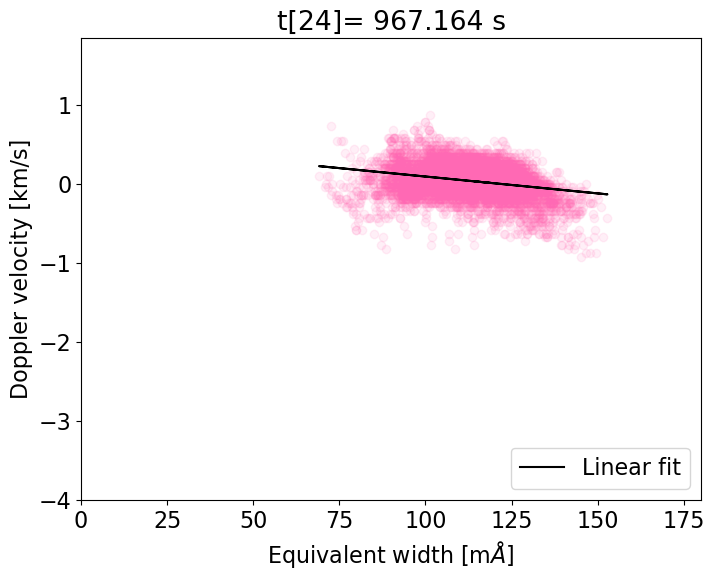

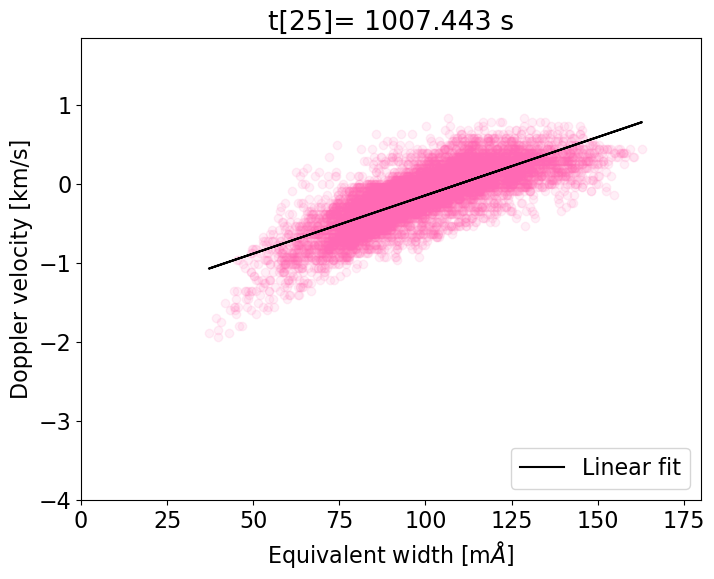

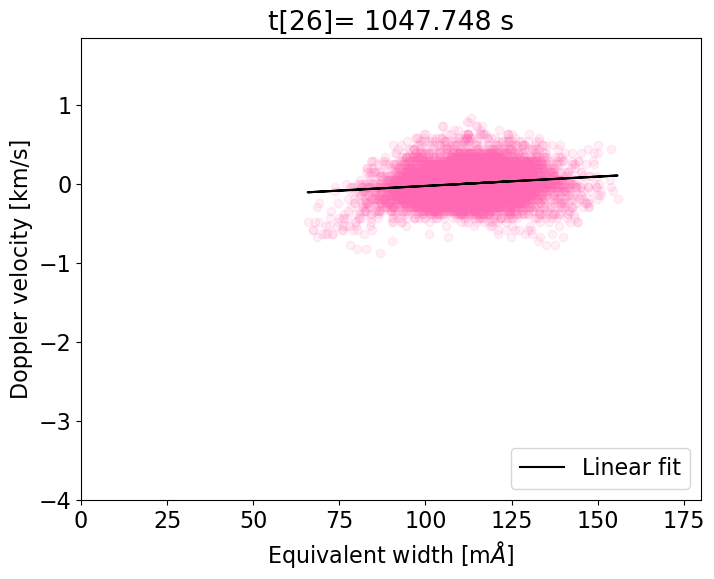

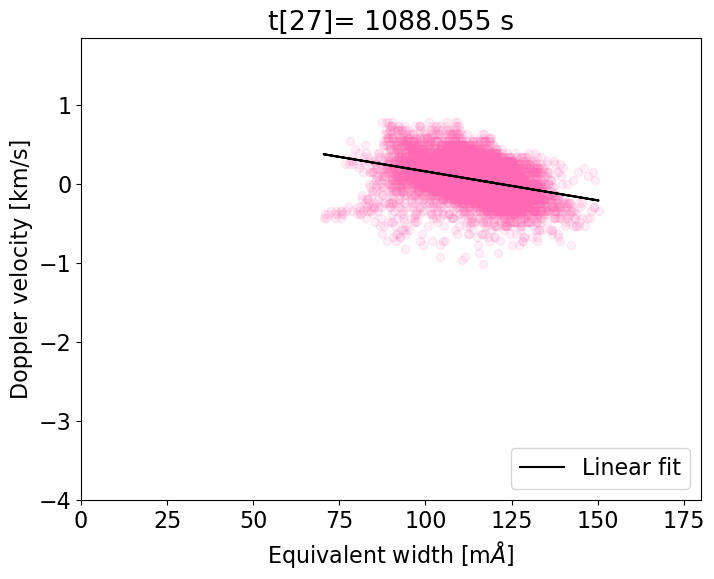

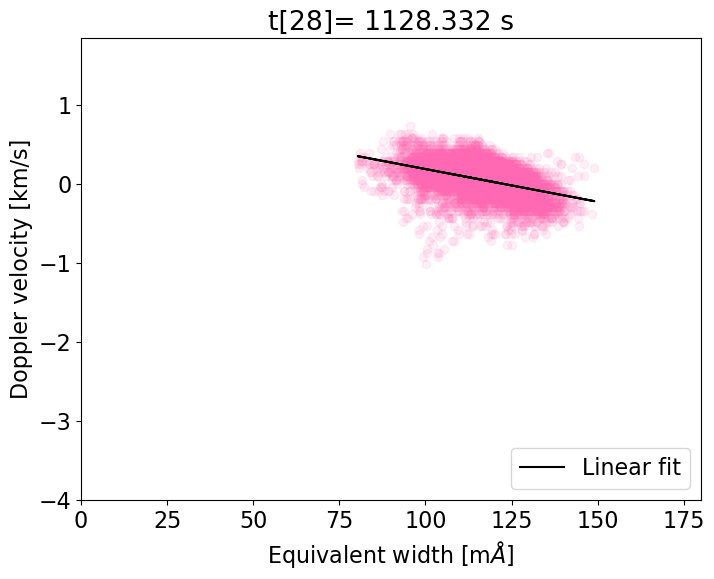

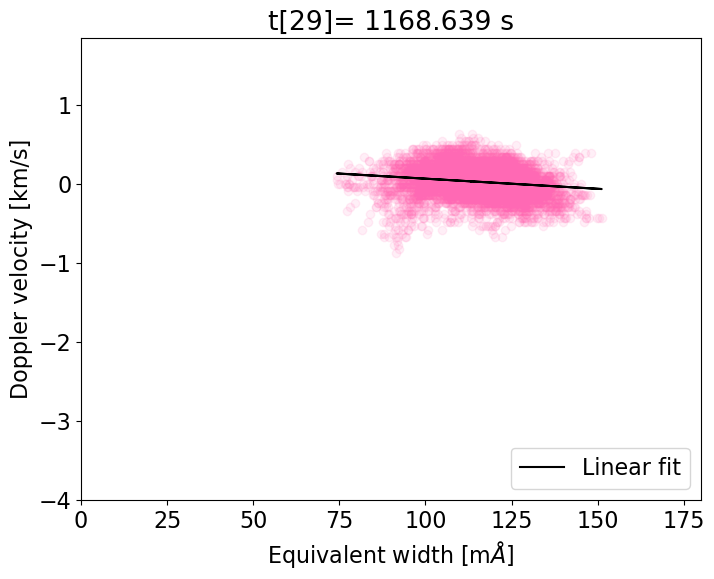

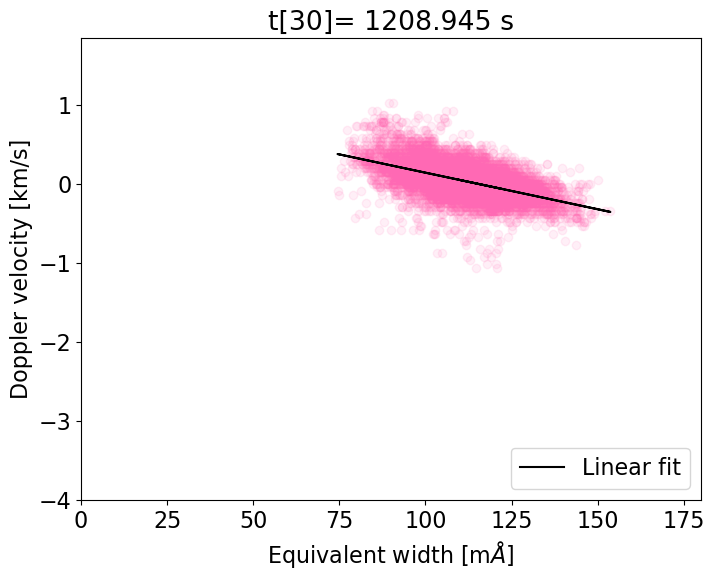

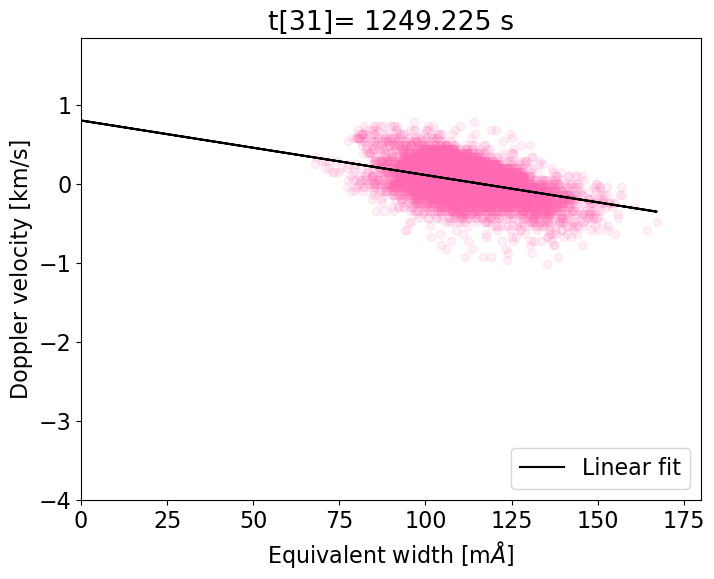

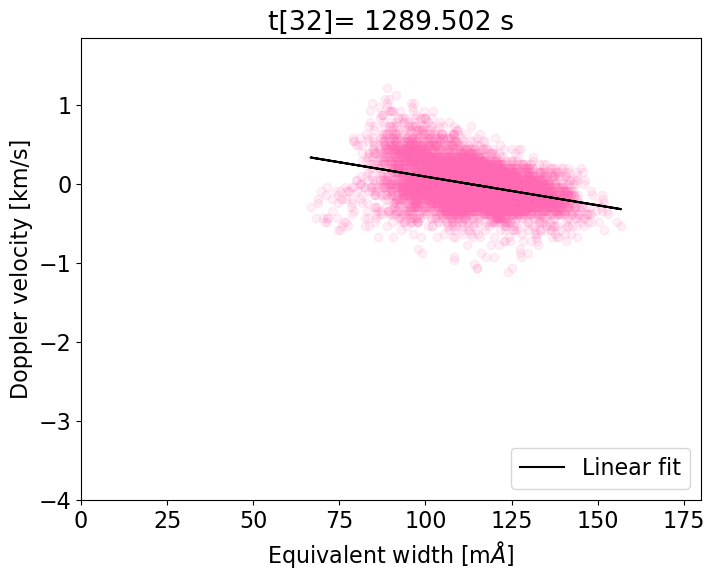

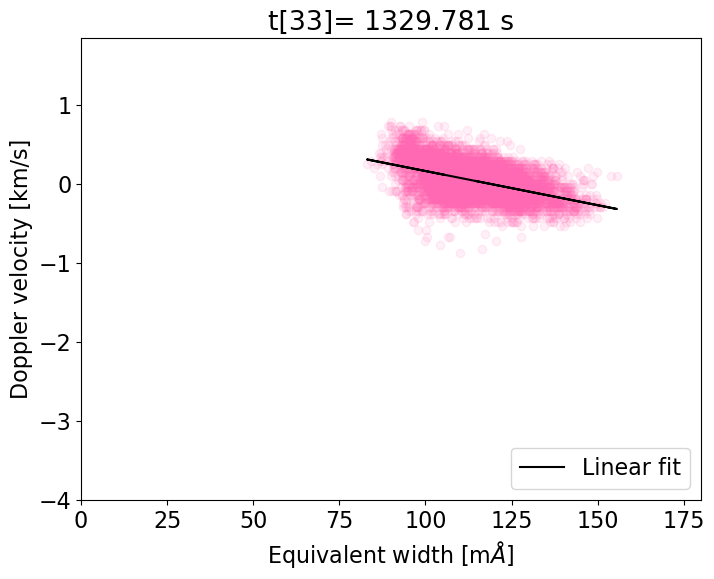

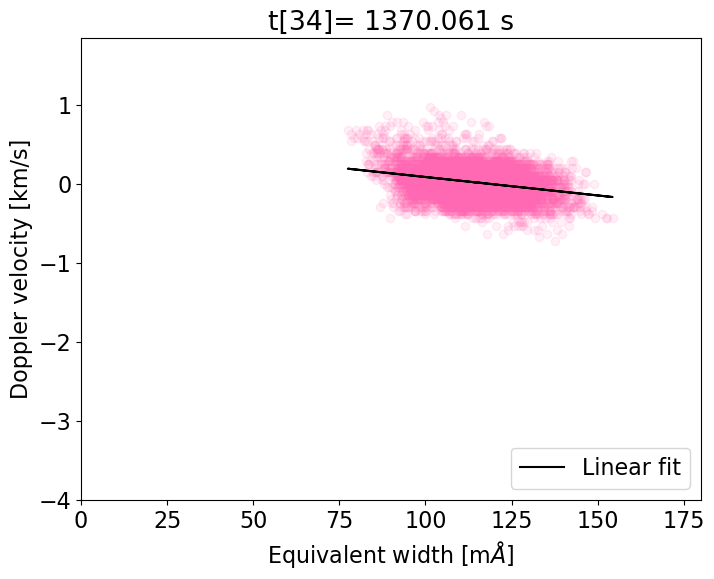

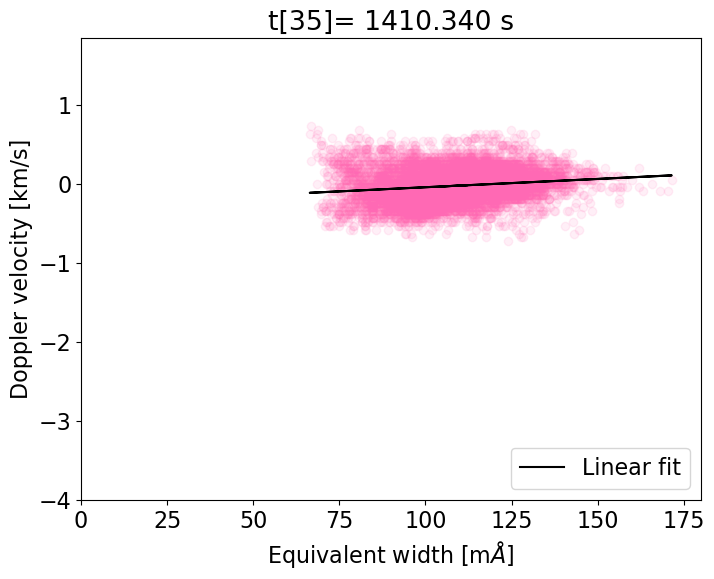

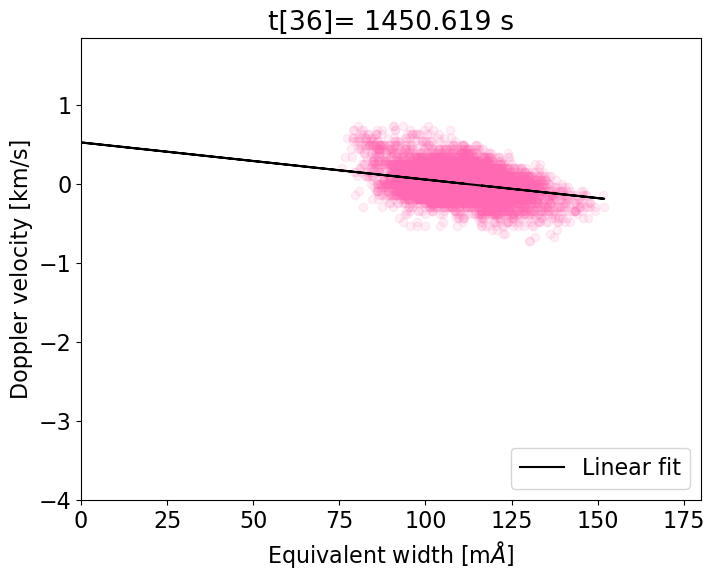

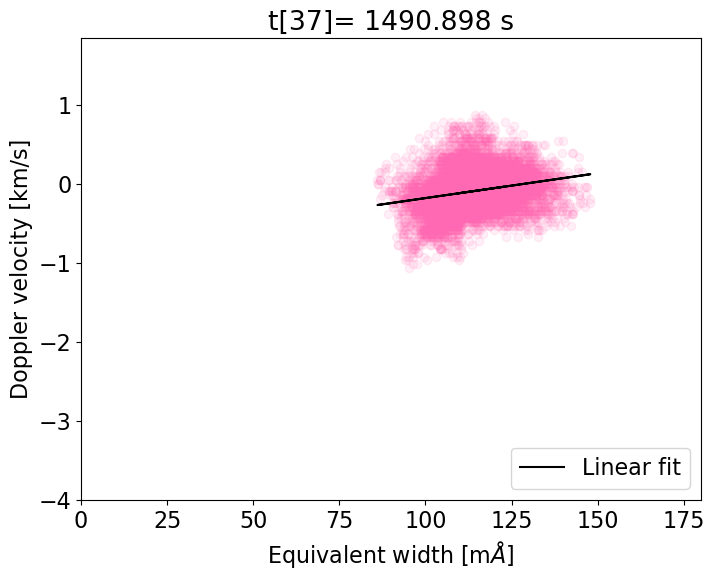

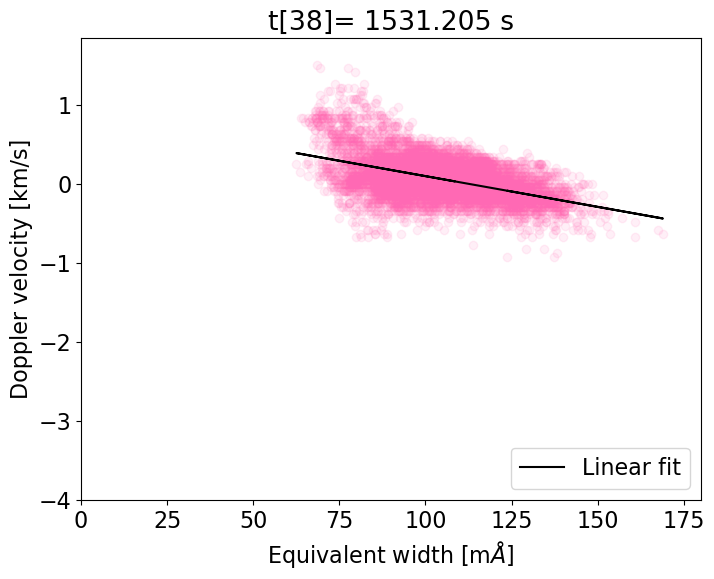

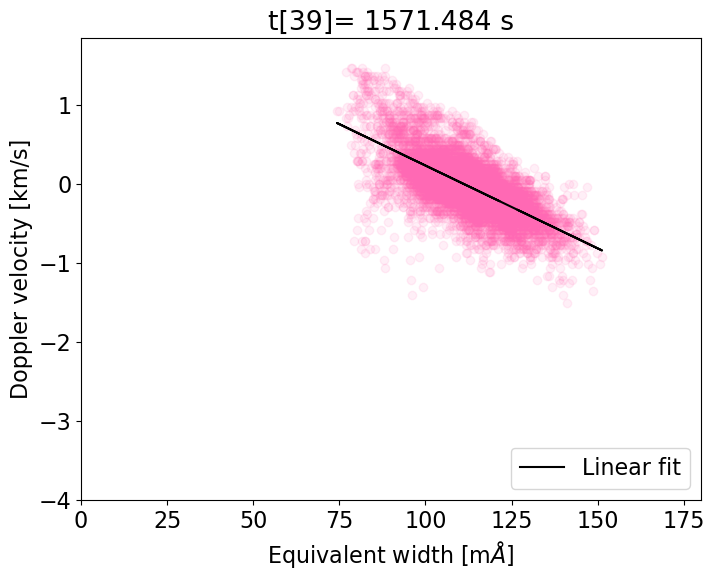

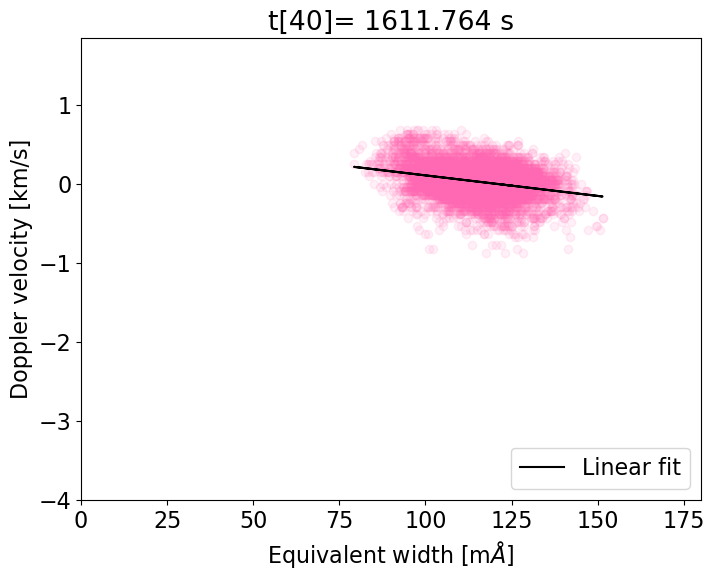

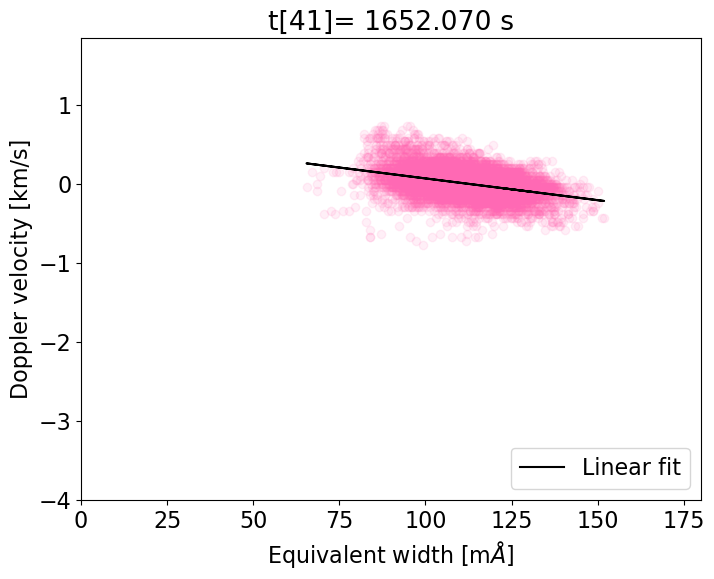

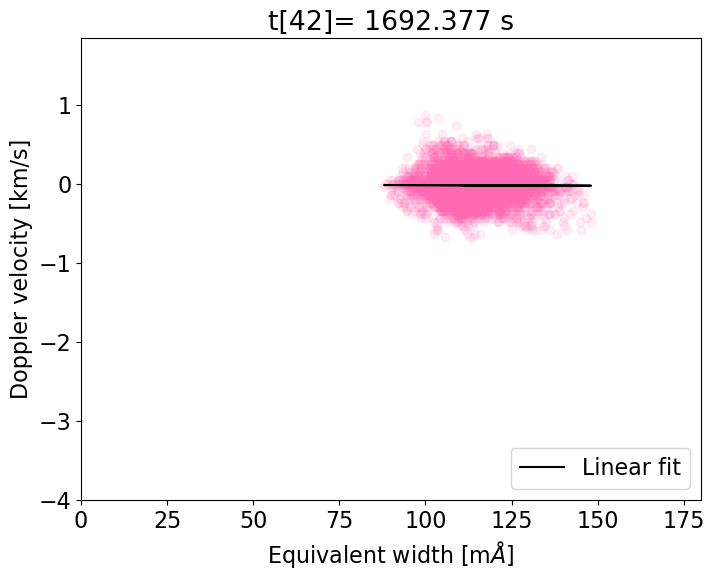

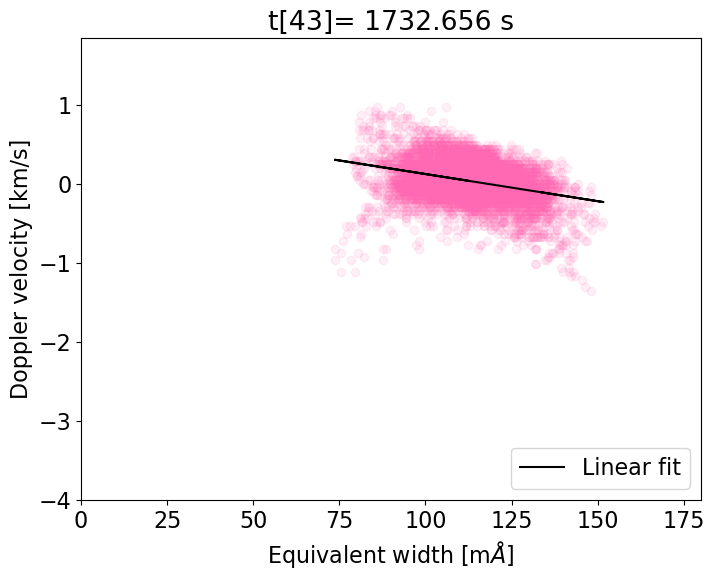

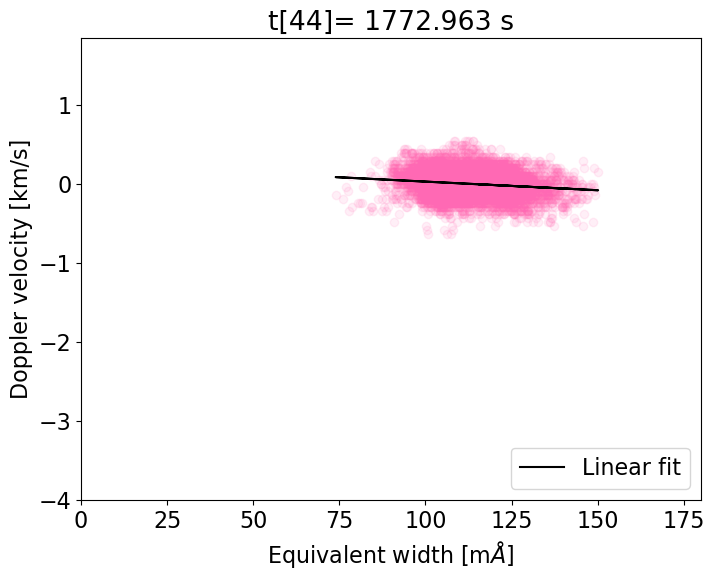

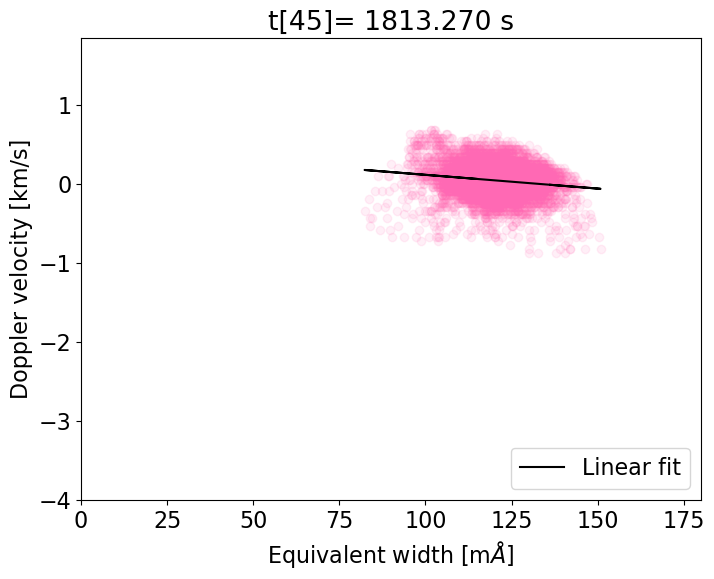

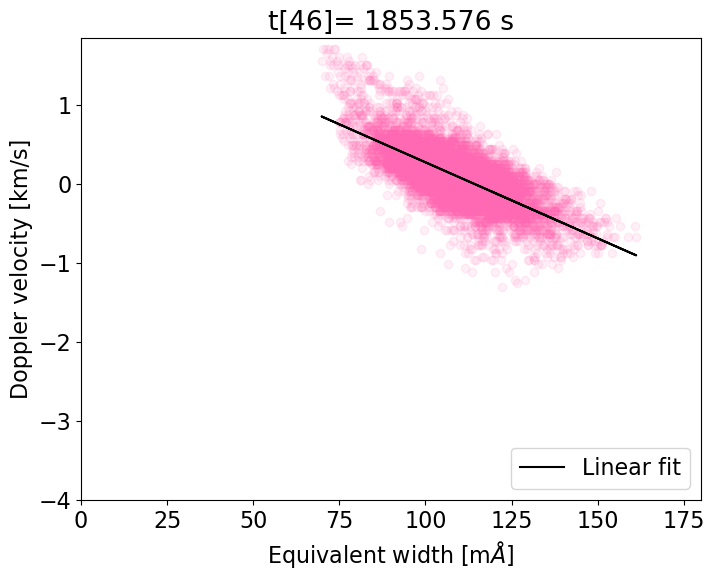

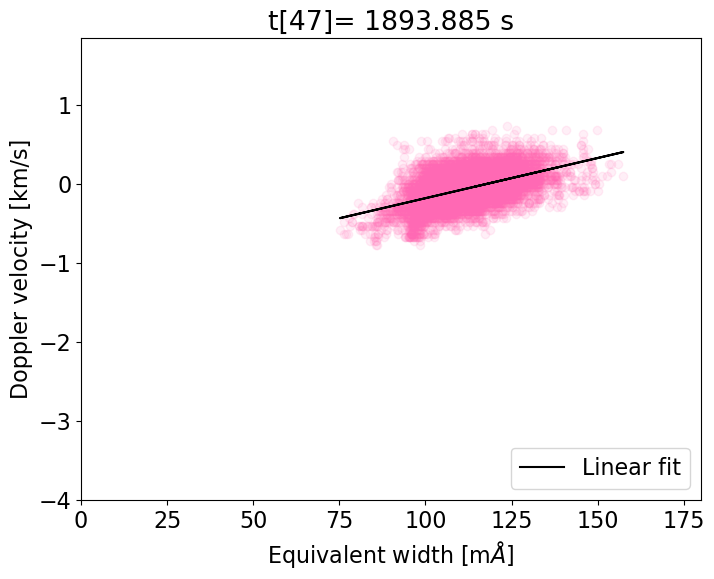

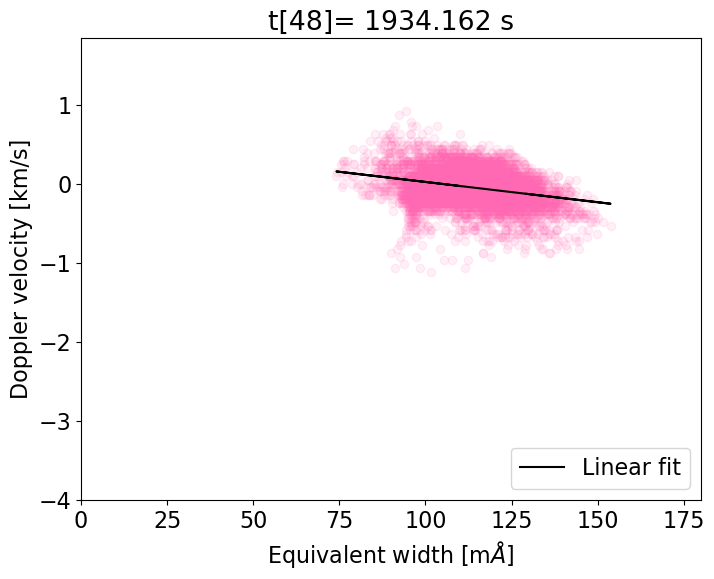

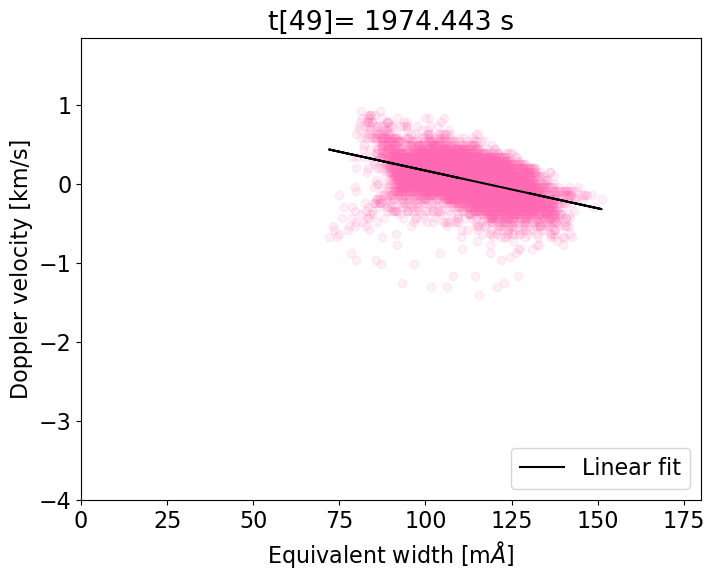

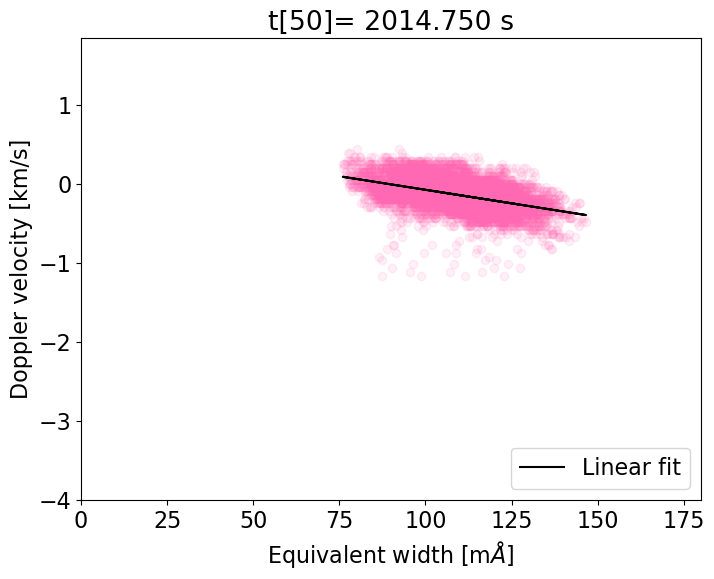

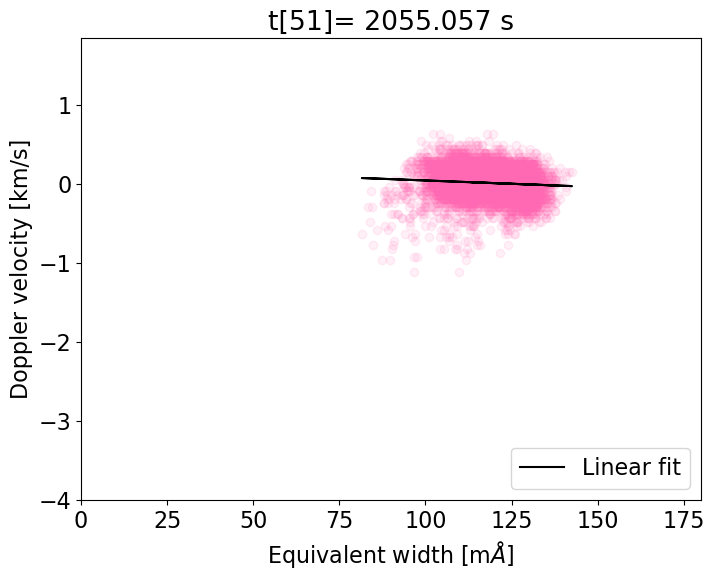

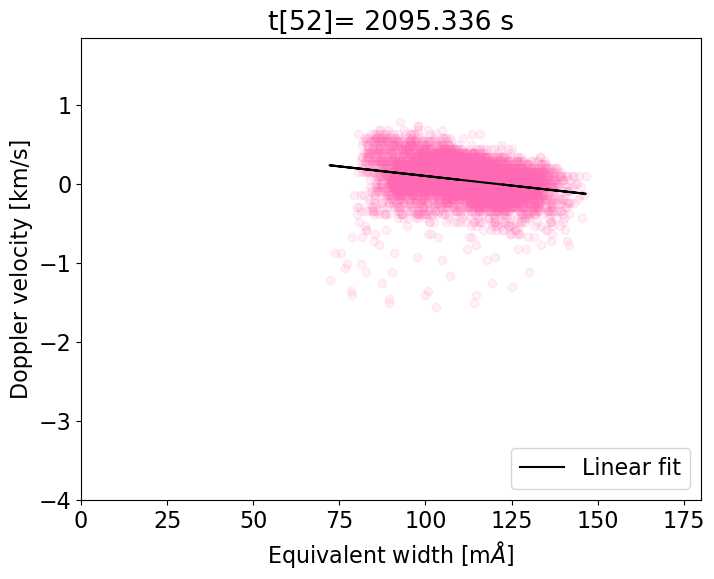

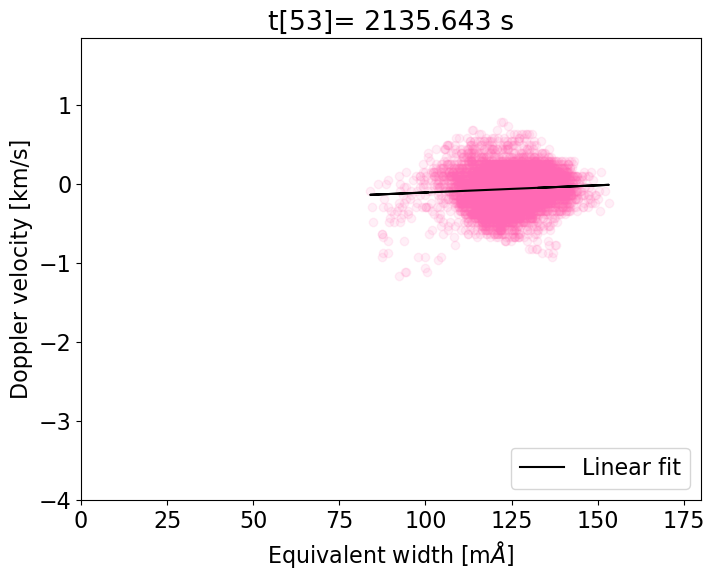

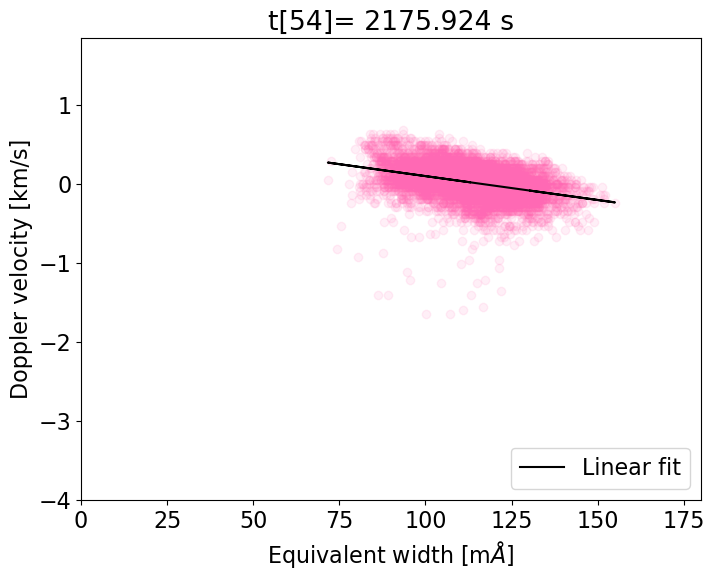

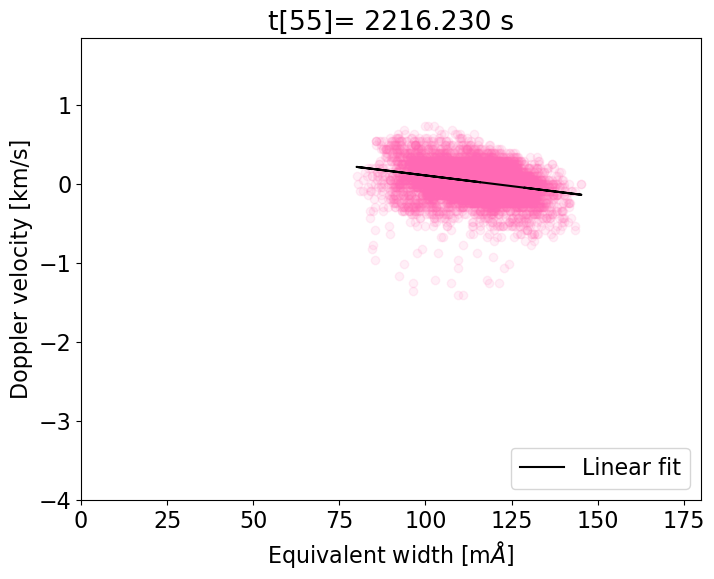

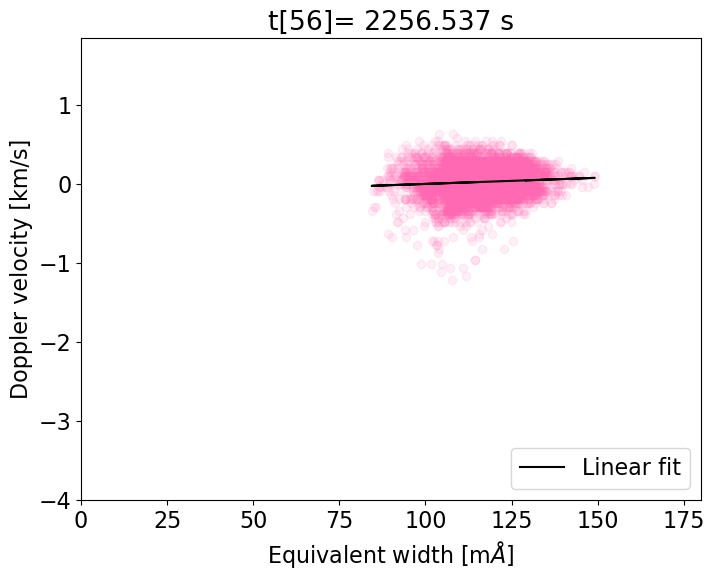

In [138]:
for t in range(len(time)):
    fig, ax = plt.subplots(figsize = (8, 6))
    print(f"Time step: {t}")

    x = ew_cube_C[t, :, :].flatten()
    y = doppler_cube_C[t, :, :].flatten()

    ax.scatter(x, y, alpha = .1, color = "hotpink")


    coefficients = np.polyfit(x, y, 1)
    slope, intercept = coefficients

    fitted_line = slope * x + intercept

    ax.plot(x, fitted_line, color='black', label='Linear fit')

    ax.set_xlim(np.min(ew_cube_C), np.max(ew_cube_C))
    ax.set_ylim(np.min(doppler_cube_C), np.max(doppler_cube_C))
    ax.set_ylim(-4, np.max(doppler_cube_C))
    ax.set_xlabel("Equivalent width [m$\AA$]")
    ax.set_ylabel("Doppler velocity [km/s]")
    ax.set_title(f't[{t}]={time_s[t]: .3f} s')
    plt.legend(loc ='lower right')
    plt.savefig(f"figures/ew_doppler_C/ew_doppler_C_{t:04d}.png")
    #plt.show()

### 6.3.6 EW vs. Doppler velocity, subfield C (w/ mask)

In [100]:
# for t in range(3):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")


#     x = ew_cube_C[t, :, :].flatten()
#     y = doppler_cube_C[t, :, :].flatten()
#     mask = intensity_mask_C[t].flatten()

#     # Split data based on intensity
#     x_high = x[mask == 1]
#     y_high = y[mask == 1]

#     x_low = x[mask == 0]
#     y_low = y[mask == 0]

#     ax.scatter(x[mask == 0], y[mask == 0], alpha=0.1, color='gray', label=r'$I \leq \frac{1}{2} I_{max}$')
#     ax.scatter(x[mask == 1], y[mask == 1], alpha=0.1, color='hotpink', label=r'$I > \frac{1}{2} I_{max}$')
    

#     # Linear fit for high-intensity points
#     if len(x_high) > 1:
#         slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
#         ax.plot(x_high, slope_high * x_high + intercept_high, color='deeppink', label='Linear fit (I > ½ max)')

#     # Linear fit for low-intensity points
#     if len(x_low) > 1:
#         slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
#         ax.plot(x_low, slope_low * x_low + intercept_low, color='dimgray', label='Linear fit (I ≤ ½ max)')

#     # Axes settings
#     ax.set_xlim(np.min(ew_cube_C), np.max(ew_cube_C))
#     ax.set_ylim(np.min(doppler_cube_C), np.max(doppler_cube_C))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}] = {time_s[t]:.3f} s')
#     ax.legend(loc='lower right')
#     #plt.savefig(f"figures/ew_doppler_mask_C/ew_doppler_mask_C_{t:04d}.png")
#     plt.show()
